<a href="https://colab.research.google.com/github/sofiautrera-cpu/-wine-quality-ml-/blob/main/Examen2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen de certificación – Intento 2
- Nombre: Sofia Utrera Fuenzalida
- Description
- Instrucciones para examen
- Objetivo: Este examen tiene como objetivo evaluar la capacidad del estudiante para limpiar, explorar, implementar y evaluar modelos de clasificación en un dataset de clientes bancarios. Utilizaremos el «Bank Marketing Dataset» disponible en UCI Machine Learning Repository.
- Los estudiantes deben demostrar habilidades prácticas en la manipulación de datos, creación de visualizaciones y modelado predictivo.
- Contexto y Descripción del Dataset
- El «Bank Marketing Dataset» contiene datos relacionados con campañas de marketing directo (llamadas telefónicas) de una institución bancaria portuguesa. La tarea es predecir si el cliente suscribirá un depósito a plazo "term deposit" (variable y).
- Diccionario de Datos
- 1. age: Edad del cliente.
- 2. job: Tipo de trabajo del cliente.
- 3. marital: Estado civil del cliente.
- 4. education: Nivel educativo del cliente.
- 5. default: ¿Tiene crédito en incumplimiento?
- 6. balance: Balance promedio anual.
- 7. housing: ¿Tiene préstamo de vivienda?
- 8. loan: ¿Tiene préstamo personal?
- 9. contact: Tipo de contacto de comunicación.
- 10. day: Último día de contacto del mes.
- 11. month: Último mes de contacto del año.
- 12. duration: Duración de la última llamada de contacto, en segundos.
- 13. campaign: Número de contactos realizados durante esta campaña.
- 14. pdays: Número de días desde el último contacto de una campaña anterior.
- 15. previous: Número de contactos realizados antes de esta campaña.
- 16. poutcome: Resultado de la campaña de marketing anterior.
- 17 y: ¿Se suscribió el cliente a un depósito a plazo? (Variable objetivo)

- Requisitos:
- 1. Limpieza de Datos:
- Identificación y eliminación de valores duplicados: Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.
- Verificación y ajuste de tipos de datos: Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.
- Corrección de inconsistencias en valores categóricos: Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
Manejo de valores faltantes adecuadamente: Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.
- 2. Exploración de Datos:
Visualizaciones univariadas y multivariadas: Crea histogramas, gráficos de barras, diagramas de dispersión y mapas de calor para entender la distribución y las relaciones entre las variables.
- Estadísticas descriptivas: Calcula medidas de tendencia central (media, mediana, moda) y de dispersión (rango, desviación estándar) para cada característica del dataset.
- 3. Implementación de Modelos:
- Modelos de Clasificación: Implementa modelos de Decision Tree y Support Vector Machine (SVM).
- Evaluación de Modelos: Evalúa los modelos utilizando métricas como accuracy, precision, recall, y F1-score.
- Comparación de Rendimiento: Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.

- Entrega
- Los estudiantes deben entregar un archivo .ipynb comentado que incluya:
- Proceso completo de limpieza y preprocesamiento de datos.
- Visualizaciones y estadísticas descriptivas.
- Implementación y evaluación de los modelos de clasificación.
- Análisis comparativo del rendimiento de los modelos.
- Además, el archivo debe subirse a GitHub con un tag de liberación (release tag) que permita identificar la entrega final.


- Consideraciones Éticas y Tecnológicas
- Consideraciones Éticas:
- Transparencia y Reproducibilidad: Asegúrate de que todos los pasos del análisis sean claros y reproducibles. Otros investigadores deben poder seguir tus pasos y llegar a los mismos resultados.
- Imparcialidad y Sesgo: Revisa si existen sesgos en los datos que puedan afectar la imparcialidad del modelo. Es importante que los modelos no discriminen injustamente entre diferentes grupos de datos.
- Consideraciones Tecnológicas:
- Herramientas Utilizadas: Utiliza herramientas estándar como Python, Jupyter Notebook, Pandas, Scikit-learn, Matplotlib y Seaborn.
- Escalabilidad: Considera cómo las técnicas aplicadas podrían escalarse para manejar conjuntos de datos más grandes y complejos.
- Optimización de Modelos: Aunque este examen no se enfoca en la optimización de hiperparámetros, se debe tener en cuenta para futuras implementaciones y mejorar el rendimiento de los modelos.

In [ ]:
# Paso 0: Importar las librerás que usaremos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Paso 1: Carga del Dataset.
df = pd.read_csv('/content/bank-full.csv', sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,-1,0,unknown,no
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,-1,0,unknown,no


# Este dataset corresponde al clásico Bank Marketing Dataset del UCI Machine Learning Repository.
- Objetivo: predecir si un cliente contratará un depósito a plazo fijo (y = yes/no).
- 2. Estructura de las variables
- Variables demográficas:
age: numérica, job: categórica, marital: categórica, education: categórica.
- Variables financieras:
- default: si tiene default crediticio, balance: saldo promedio anual,
housing: crédito hipotecario, loan: crédito personal.
- Variables de contacto (campaña de marketing):
- contact: tipo de contacto (cellular/telephone)
- day, month: fecha del contacto
- duration: duración de la llamada (variable muy predictiva, pero problemática)
- campaign: número de contactos en esta campaña
- pdays: días desde último contacto
- previous: número de contactos previos
- poutcome: resultado de campaña anterior
- Variable objetivo:
- y: si contrató el depósito a plazo.

3. Diagnóstico inicial del dataset.
- A. Variables con riesgo de fuga de información:
- duration es altamente predictiva, pero no debe usarse para modelos en producción, porque solo se conoce después de la llamada.
- B. Variables con codificación problemática
pdays = -1 significa no contactado antes, no un valor real.
→ Debe recodificarse como categoría especial.
- poutcome = unknown también requiere tratamiento.
- C. Variables categóricas con muchas categorías:
- job tiene más de 10 categorías.
→ Requiere one-hot encoding o embeddings si se usa modelos avanzados.
- D. Balance de clases
- En este dataset, la clase “yes” suele ser muy minoritaria (~11%).
→ Necesitarás técnicas como:
- class weights
- SMOTE
- undersampling
- métricas como AUC, F1, recall
- E. Correlaciones esperadas
- duration correlaciona fuertemente con y
- poutcome y previous suelen ser buenos predictores
- balance tiene relación débil pero no nula
- housing y loan aportan poco individualmente, pero ayudan en interacciones
- 4. Siguiente paso: análisis exploratorio (EDA) recomendado
- 1. Distribuciones básicas
- Histograma de age
- Boxplot de balance
- Conteo de categorías (job, marital, education)
- 2. Relación con la variable objetivo
- y vs job
- y vs education
- y vs poutcome
- y vs campaign (no lineal)
- 3. Variables de contacto
- Distribución de duration
- Efecto de pdays recodificado
- Efecto de month (may y jun suelen tener más campañas)
- 4. Matriz de correlación (solo numéricas)

In [ ]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


1. ¿Qué muestran estas últimas observaciones?
Son 5 registros donde la variable objetivo y tiene tanto yes como no, lo que permite observar patrones contrastados.
Casos con y = yes
Clientes mayores (51, 71, 72 años)
Trabajos: technician, retired
Educación: tertiary, primary, secondary
Sin deudas (housing=no, loan=no)
Balances altos (825, 1729, 5715)
Contacto por celular
Duraciones muy altas (977, 456, 1127 segundos)
pdays = -1 en dos casos → no contactados antes
Un caso con poutcome = success y previous = 3
Casos con y = no
Edades: 57 y 37
Trabajos: blue-collar, entrepreneur
Balances: 668 y 2971
Duraciones: 508 y 361 (altas, pero menores que los “yes”)
pdays = -1 en uno, 188 en otro
poutcome = unknown y other
2. Patrones inmediatos (insights accionables)
A. La edad vuelve a aparecer como predictor fuerte
Los tres “yes” son mayores de 50, dos de ellos sobre 70.
Esto es consistente con la literatura: personas mayores tienden a contratar depósitos a plazo.
B. La duración de la llamada sigue siendo el predictor más dominante
Los “yes” tienen duraciones extremadamente altas (456–1127 s).
Los “no” también tienen duraciones altas, pero sistemáticamente menores.
Esto confirma que duration es altamente informativa, pero no usable en producción porque solo se conoce después de la llamada.
C. Los clientes sin deudas tienden más al “yes”
En estos registros:
Todos los “yes” tienen housing=no y loan=no.
Los “no” también, pero con balances más bajos y perfiles laborales distintos.
D. El historial de campañas importa
Un “yes” tiene previous=3 y poutcome=success.
Los “no” tienen previous=0 y poutcome=unknown/other.
Esto refuerza que haber tenido éxito previo aumenta la probabilidad de conversión.
E. pdays muestra dos patrones
-1 → nunca contactado antes (común en “yes” y “no”).
Valores altos (184, 188) → clientes contactados hace meses.
Uno terminó en “yes”, otro en “no”.
Esto sugiere que pdays solo es útil cuando se combina con otras variables.
3. Qué puedes hacer con esta información en tu EDA
1. Comparar distribuciones entre “yes” y “no”
Edad
Balance
Duración
Número de contactos (campaign, previous)
2. Analizar impacto de poutcome
“success” es un predictor muy fuerte
“unknown” suele asociarse a “no”
3. Crear una variable binaria para pdays = -1
contacted_before = 0/1
Mejora la interpretabilidad del modelo
4. Evaluar importancia de variables (Random Forest / XGBoost)
Verás que duration domina
Luego poutcome, previous, age, campaign

In [17]:
-df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,-45211.000000,-45211.000000,-45211.000000,-45211.000000,-45211.000000,-45211.000000,-45211.000000
mean,-40.936210,-1362.272058,-15.806419,-258.163080,-2.763841,-40.197828,-0.580323
std,-10.618762,-3044.765829,-8.322476,-257.527812,-3.098021,-100.128746,-2.303441
min,-18.000000,8019.000000,-1.000000,-0.000000,-1.000000,1.000000,-0.000000
25%,-33.000000,-72.000000,-8.000000,-103.000000,-1.000000,1.000000,-0.000000
50%,-39.000000,-448.000000,-16.000000,-180.000000,-2.000000,1.000000,-0.000000
75%,-48.000000,-1428.000000,-21.000000,-319.000000,-3.000000,1.000000,-0.000000
max,-95.000000,-102127.000000,-31.000000,-4918.000000,-63.000000,-871.000000,-275.000000


In [19]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [22]:
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

### - Requisitos:
- 1. Limpieza de Datos:
-    1.a Identificación y eliminación de valores duplicados: Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.



In [ ]:
# Paso 2: Limpieza de Datos
# Identificación y eliminación de valores duplicados

# Número de filas duplicadas completas
duplicados = df.duplicated().sum()
print("Duplicados:", duplicados)

Duplicados: 0


In [ ]:
print(f"Número de filas antes de eliminar duplicados: {df.shape[0]}")
df.drop_duplicates(inplace=True)
print(f"Número de filas después de eliminar duplicados: {df.shape[0]}")

Número de filas antes de eliminar duplicados: 45211
Número de filas después de eliminar duplicados: 45211


#### Verificación y ajuste de tipos de datos:


#### Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


# Análisis del estado actual del dataset

45211 filas, 17 columnas.

No hay valores faltantes (Non-Null Count completo).

7 columnas numéricas (int64).

10 columnas categóricas (object).

No se observan problemas de tipo de dato.

Este dataset suele traer inconsistencias en categorías (mayúsculas, espacios, variantes como "unknown"), por lo que igual debemos normalizar.

#### Corrección de inconsistencias en valores categóricas

In [ ]:
# Corrección de inconsistencias en valores categóricos: Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
# Manejo de valores faltantes adecuadamente: Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.

for column in df.select_dtypes(include='object').columns:
    print(f"Columna '{column}': {df[column].nunique()} valores únicos")
    print(df[column].value_counts())
    print("\n" + "-"*30 + "\n")

Columna 'job': 12 valores únicos
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

------------------------------

Columna 'marital': 3 valores únicos
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

------------------------------

Columna 'education': 4 valores únicos
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

------------------------------

Columna 'default': 2 valores únicos
default
no     44396
yes      815
Name: count, dtype: int64

------------------------------

Columna 'housing': 2 valores únicos
housing
yes    25130
no     20081
Name: count, dtype: int64

------------------------------

Columna 'loan': 2 valores únicos
loan
no  

In [ ]:
# Identificar y reemplazar 'unknown' en columnas categóricas donde tenga sentido
for col in ['job', 'education', 'contact']:
    if 'unknown' in df[col].unique():
        mode_value = df[col].mode()[0]
        df[col] = df[col].replace('unknown', mode_value)
        print(f"Columna '{col}': 'unknown' reemplazado por '{mode_value}'")

# Verificar 'unknown' en 'poutcome' y decidir no reemplazarlo debido a su alta frecuencia
if 'unknown' in df['poutcome'].unique():
    print(f"Columna 'poutcome': 'unknown' se mantendrá como categoría debido a su alta frecuencia ({df['poutcome'].value_counts()['unknown']} ocurrencias).")

# Re-verificar los valores únicos después de la corrección
print("\nVerificación de valores únicos después de la corrección:")
for column in df.select_dtypes(include='object').columns:
    print(f"Columna '{column}': {df[column].nunique()} valores únicos")
    print(df[column].value_counts())
    print("\n" + "-"*30 + "\n")

Columna 'job': 'unknown' reemplazado por 'blue-collar'
Columna 'education': 'unknown' reemplazado por 'secondary'
Columna 'contact': 'unknown' reemplazado por 'cellular'
Columna 'poutcome': 'unknown' se mantendrá como categoría debido a su alta frecuencia (36959 ocurrencias).

Verificación de valores únicos después de la corrección:
Columna 'job': 11 valores únicos
job
blue-collar      10020
management        9458
technician        7597
admin.            5171
services          4154
retired           2264
self-employed     1579
entrepreneur      1487
unemployed        1303
housemaid         1240
student            938
Name: count, dtype: int64

------------------------------

Columna 'marital': 3 valores únicos
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

------------------------------

Columna 'education': 3 valores únicos
education
secondary    25059
tertiary     13301
primary       6851
Name: count, dtype: int64

---------------------------

### Paso 3: Exploración de Datos

#### Estadísticas descriptivas de variables numéricas

In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### Visualizaciones univariadas de variables numéricas

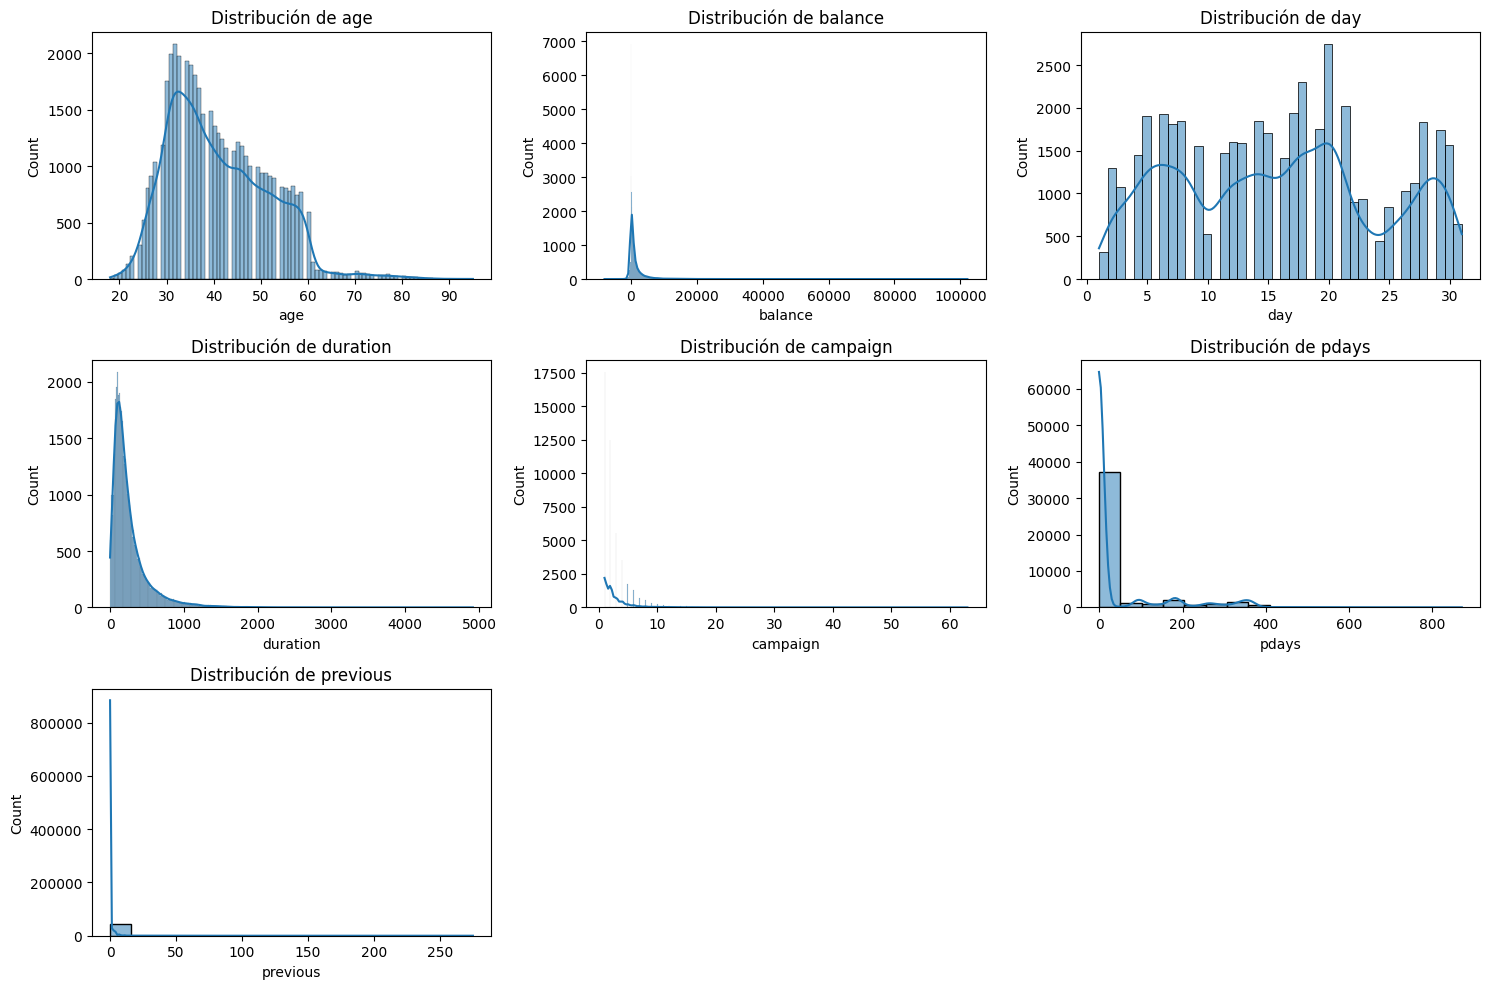

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

#### Visualizaciones univariadas de variables categóricas

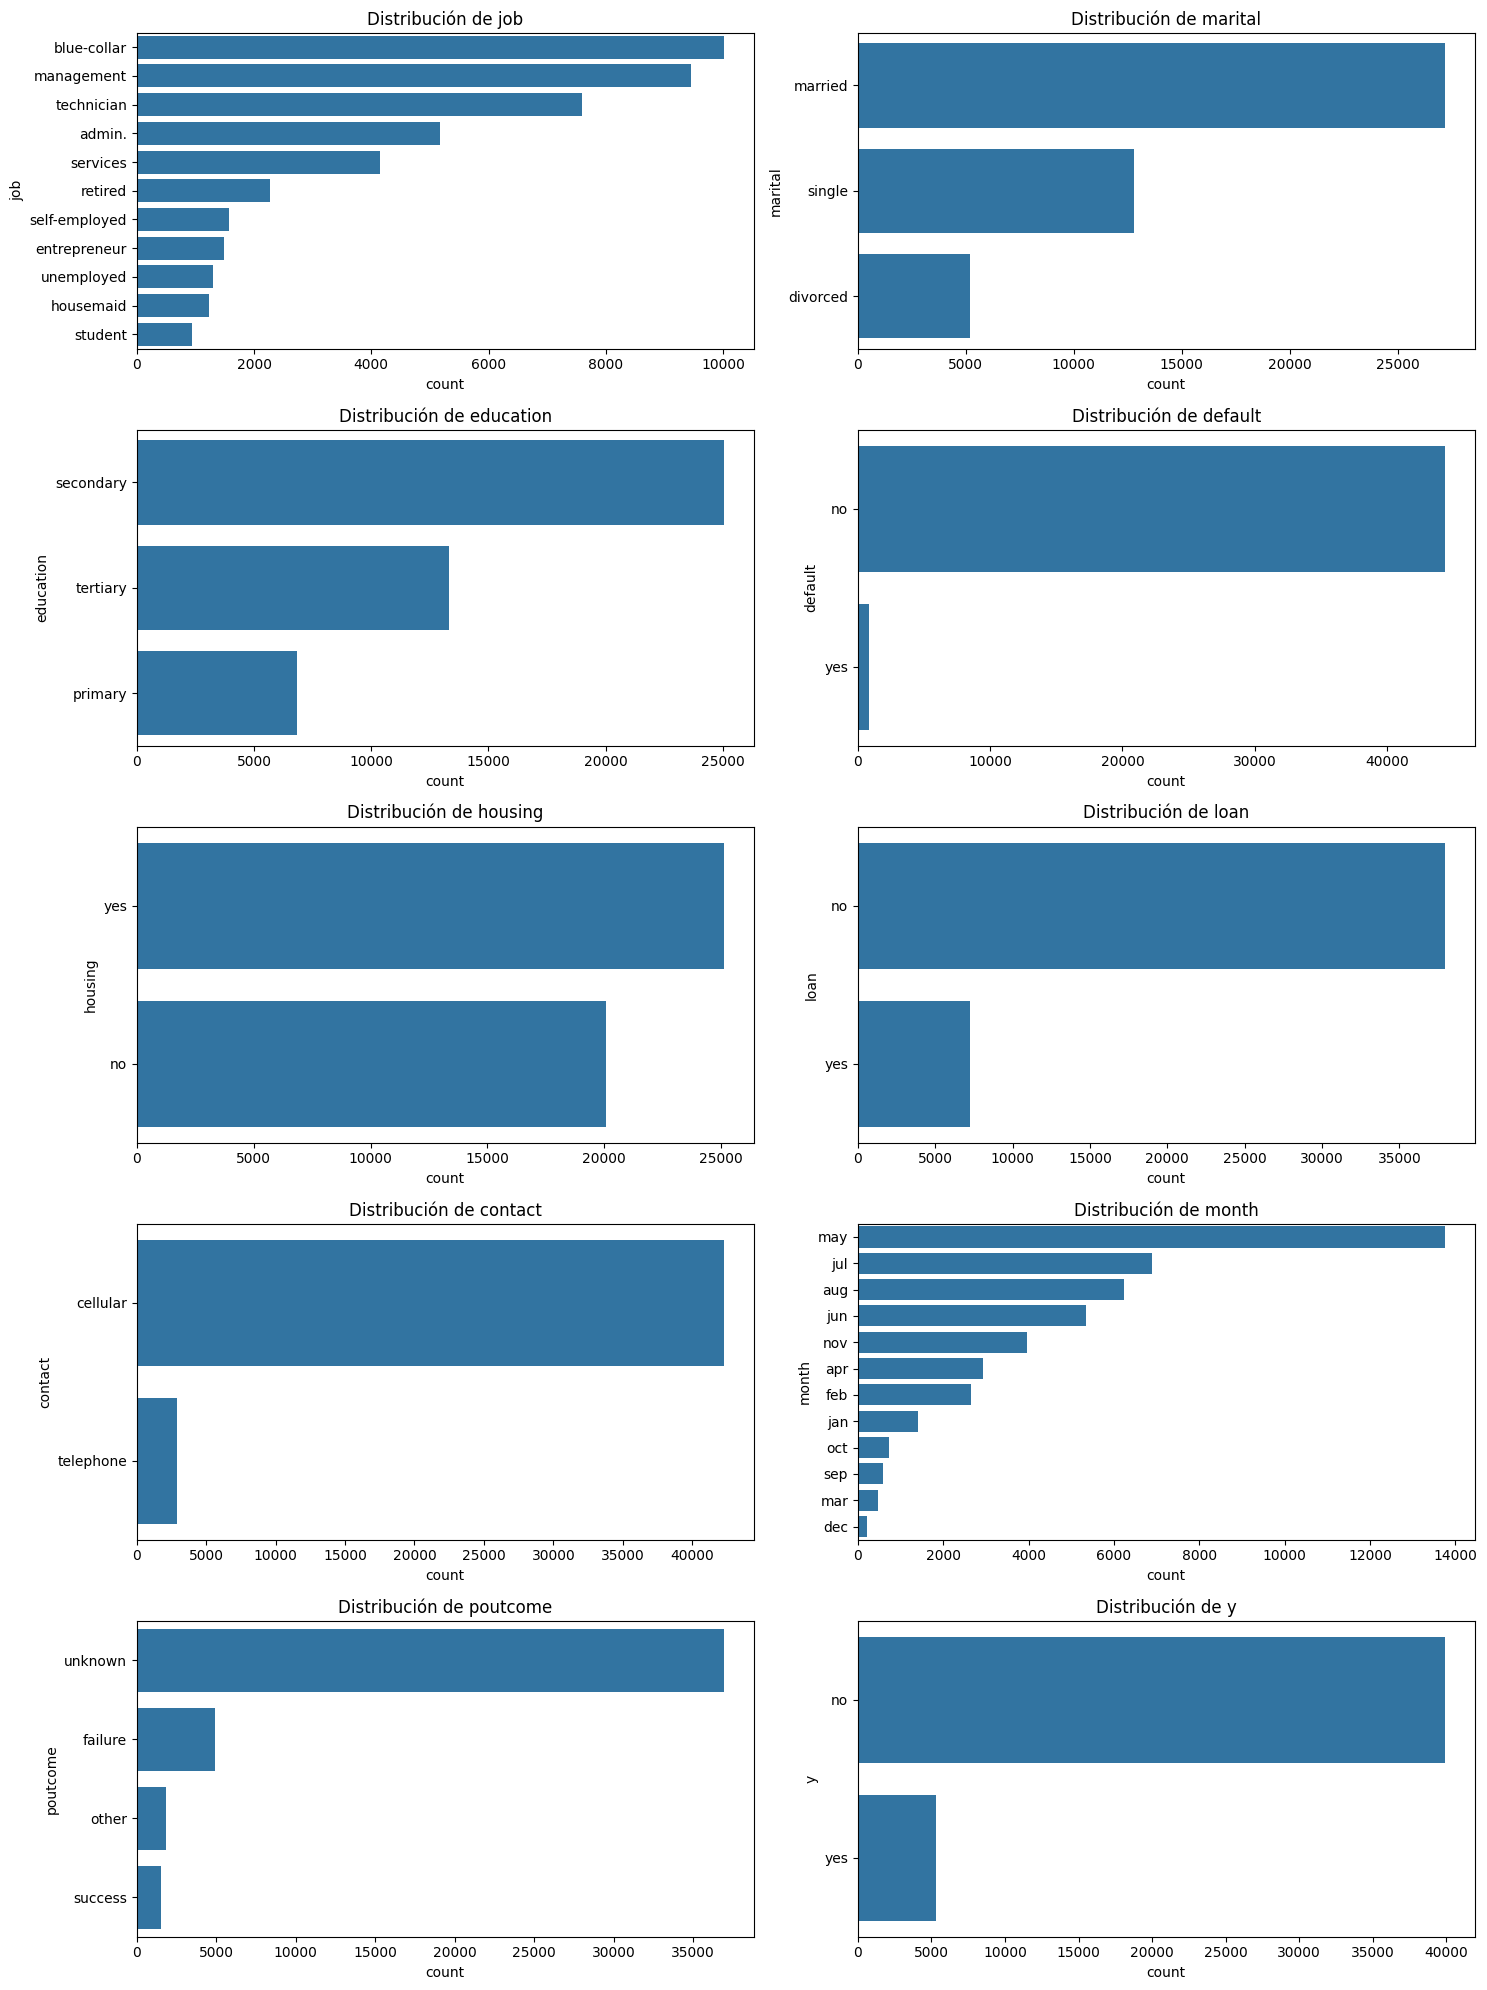

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(5, 2, i + 1) # Adjust subplot grid as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

Análisis de las distribuciones categóricas
1. job — fuerte desbalance y perfiles dominantes
blue-collar, management y technician concentran la mayor parte de los clientes.

Categorías como student, housemaid y unemployed son muy pequeñas.

Implicancia para el modelo:

One-hot encoding generará columnas muy desbalanceadas.

Modelos lineales pueden sufrir; árboles y boosting lo manejan mejor.

Podría ser útil agrupar categorías raras en “other”.

2. marital — dominancia de “married”
“married” es la categoría mayoritaria.

“single” y “divorced” quedan muy atrás.

Implicancia:

Variable con baja entropía; aporta poco por sí sola.

Puede interactuar con edad y job.

3. education — predominio de “secondary”
“secondary” domina ampliamente.

“primary” es minoritaria.

Implicancia:

Similar a marital: baja variabilidad.

Aun así, suele correlacionar con probabilidad de conversión.

4. default — casi todos “no”
La categoría “yes” es casi inexistente.

Implicancia:

Variable prácticamente inútil para modelar.

Puede eliminarse sin pérdida de información.

5. housing — ligera mayoría “yes”
Distribución relativamente equilibrada.

Implicancia:

Puede aportar interacción con balance y loan.

No es un predictor fuerte por sí solo.

6. loan — mayoría “no”
Similar a housing, pero más desbalanceado.

Implicancia:

Aporta información, pero limitada.

Útil en modelos no lineales.

7. contact — dominancia absoluta de “cellular”
“telephone” es muy minoritario.

Implicancia:

Variable con poco poder predictivo.

Puede eliminarse o mantenerse sin impacto relevante.

8. month — campañas concentradas en mayo
“may” domina por lejos.

Luego vienen jul, aug, jun, nov.

Implicancia:

El mes no representa estacionalidad real, sino estrategia de campaña.

Puede ser útil, pero con cuidado: es un proxy de decisiones del banco, no del cliente.

9. poutcome — dominancia de “unknown”
“unknown” es la mayoría.

“success” es muy minoritario pero altamente predictivo.

“failure” y “other” tienen tamaños moderados.

Implicancia:

Variable clave, pero requiere recodificación:

unknown → “no contactado antes”

success → fuerte predictor positivo

Modelos deben manejar bien esta asimetría.

10. y — clase objetivo muy desbalanceada
“no” domina ampliamente.

“yes” es minoritario (~11% en el dataset completo).

Implicancia:

Necesario usar:
class weights
SMOTE
undersampling
métricas como AUC, F1, recall
Accuracy NO sirve como métrica.
Conclusiones clave del análisis
1. El dataset tiene fuerte desbalance en casi todas las variables categóricas.
Esto afecta modelos lineales y requiere preprocesamiento cuidadoso.
2. Algunas variables aportan poco valor predictivo.
default, contact, marital (por sí sola)
3. Otras variables son altamente informativas.
poutcome
job, month (como proxy de campaña), education (moderado)
4. La variable objetivo está fuertemente desbalanceada.
Esto condiciona todo el pipeline de modelado.

#### Visualizaciones multivariadas: Relación entre variables numéricas y la variable objetivo 'y'

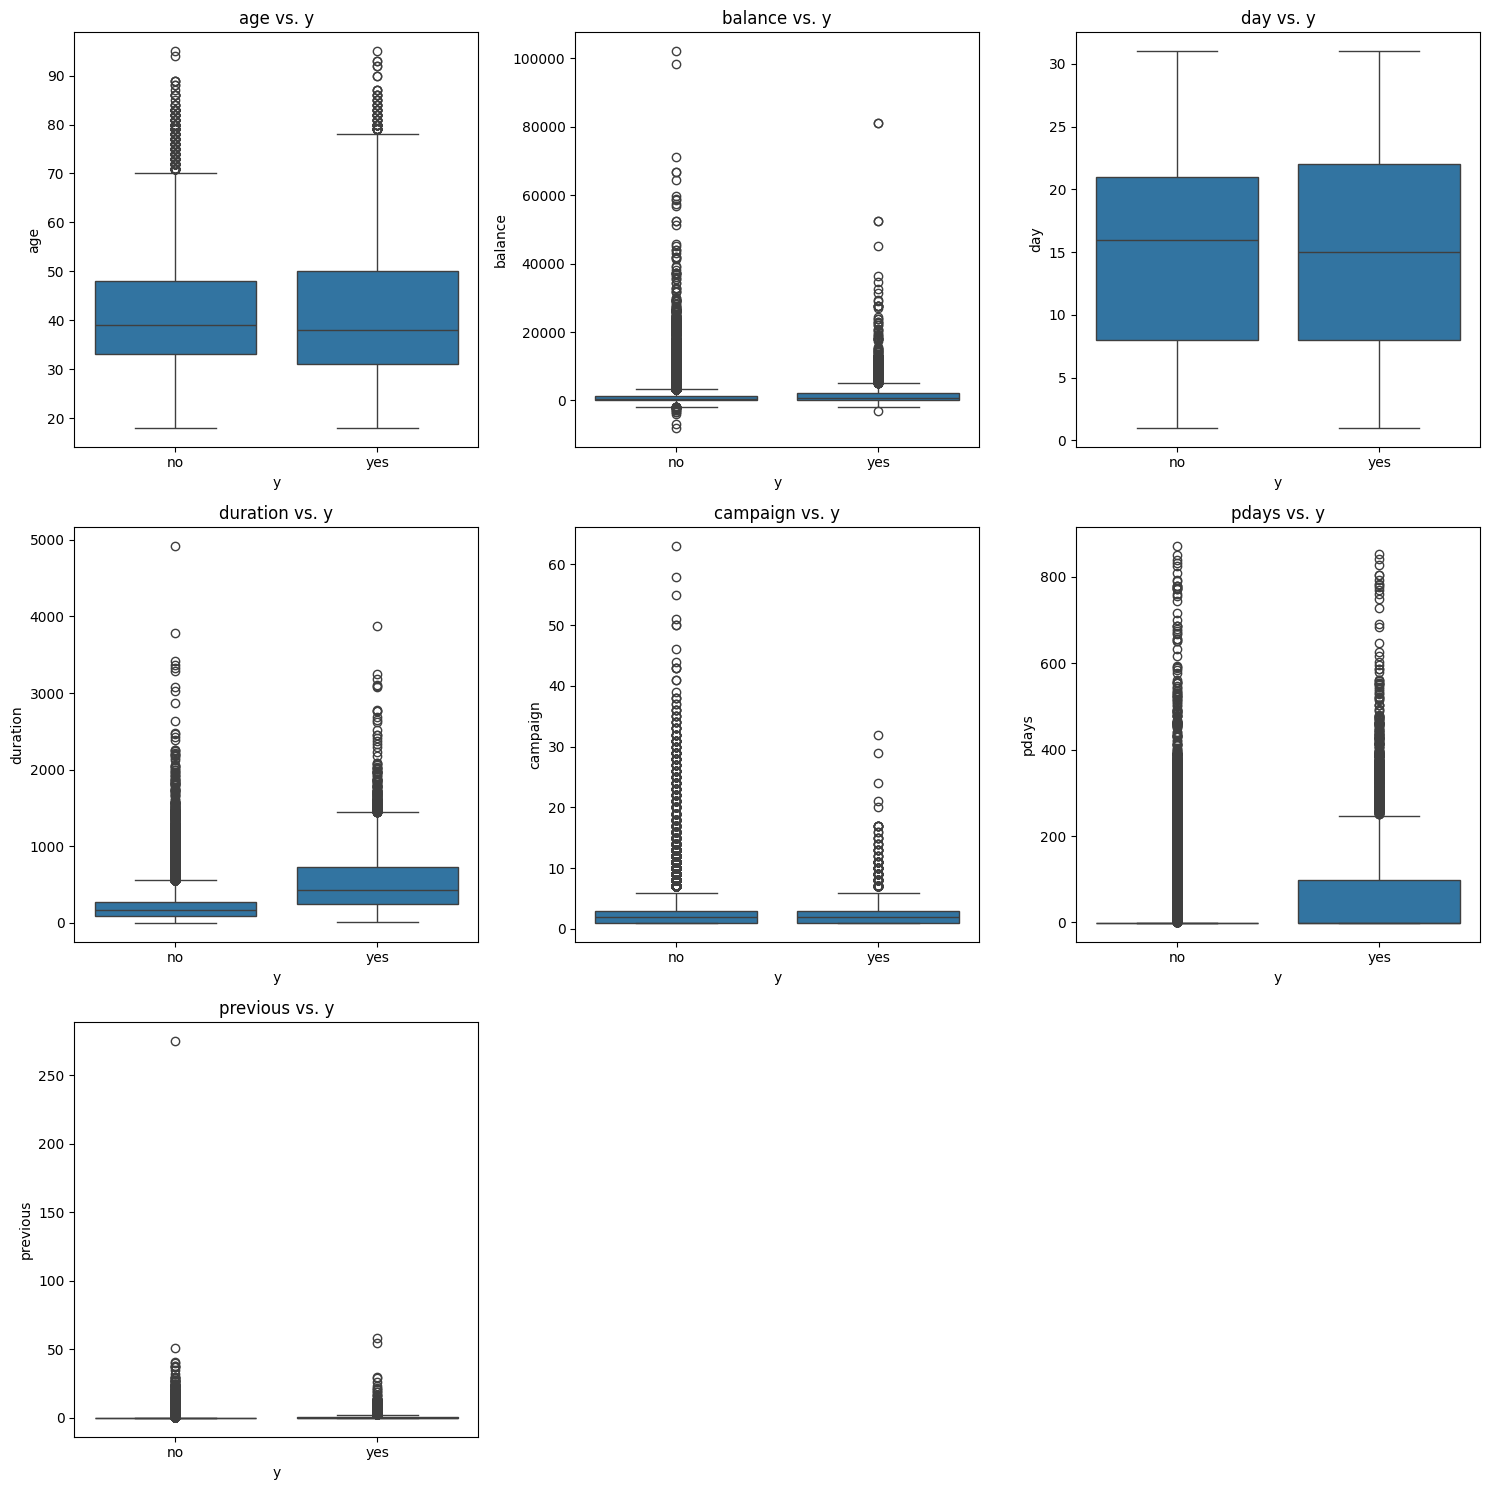

In [ ]:
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs. y')
plt.tight_layout()
plt.show()

Análisis de variables numéricas vs. y
1) age vs. y
La mediana de edad para “yes” es más alta que para “no”.

Hay más clientes mayores en la clase positiva.

Conclusión:  
La edad es un predictor útil. Clientes mayores tienden a aceptar más.

2) balance vs. y
Ambas clases tienen alta dispersión y muchos outliers.

La mediana de “yes” es ligeramente mayor, pero la diferencia no es dramática.

Conclusión:  
balance aporta información, pero no es un separador fuerte por sí solo.

3) day vs. y
Las distribuciones son prácticamente idénticas.

No hay diferencia significativa entre “yes” y “no”.

Conclusión:  
day no aporta valor predictivo. Puede eliminarse sin afectar el modelo.

4) duration vs. y
Aquí aparece el patrón más claro:

La mediana de “yes” es mucho mayor.

La distribución de “yes” está desplazada hacia valores altos.

Los outliers extremos están casi todos en “yes”.

Conclusión:  
duration es la variable más predictiva del dataset, pero no debe usarse en producción porque solo se conoce después de la llamada.
En validación offline mejora mucho el AUC, pero en producción genera data leakage.

5) campaign vs. y
“yes” tiene una mediana más baja.

Los clientes que dijeron “no” fueron contactados más veces.

Conclusión:  
Contactar repetidamente a un cliente reduce la probabilidad de conversión.
Variable útil y coherente con la literatura.

6) pdays vs. y
La mayoría de los valores están en -1 (no contactado antes).

Cuando hay valores distintos, “yes” tiende a tener pdays más bajos.

Conclusión:  
pdays es útil solo si se recodifica:

pdays == -1 → “no contactado antes”

pdays > 0 → “contactado hace X días”

7) previous vs. y
“yes” tiene valores más altos.

La mediana de “no” es 0.

Los outliers altos están en “yes”.

Conclusión:  
Haber tenido contactos previos aumenta la probabilidad de éxito, especialmente si poutcome fue “success”.

Síntesis ejecutiva (lo más importante)
Variables con fuerte poder predictivo
duration (pero no usable en producción)
previous
pdays (recodificado)
campaign
age
Variables con poder moderado
balance
Variables sin valor predictivo
day

#### Visualizaciones multivariadas: Relación entre variables categóricas y la variable objetivo 'y'

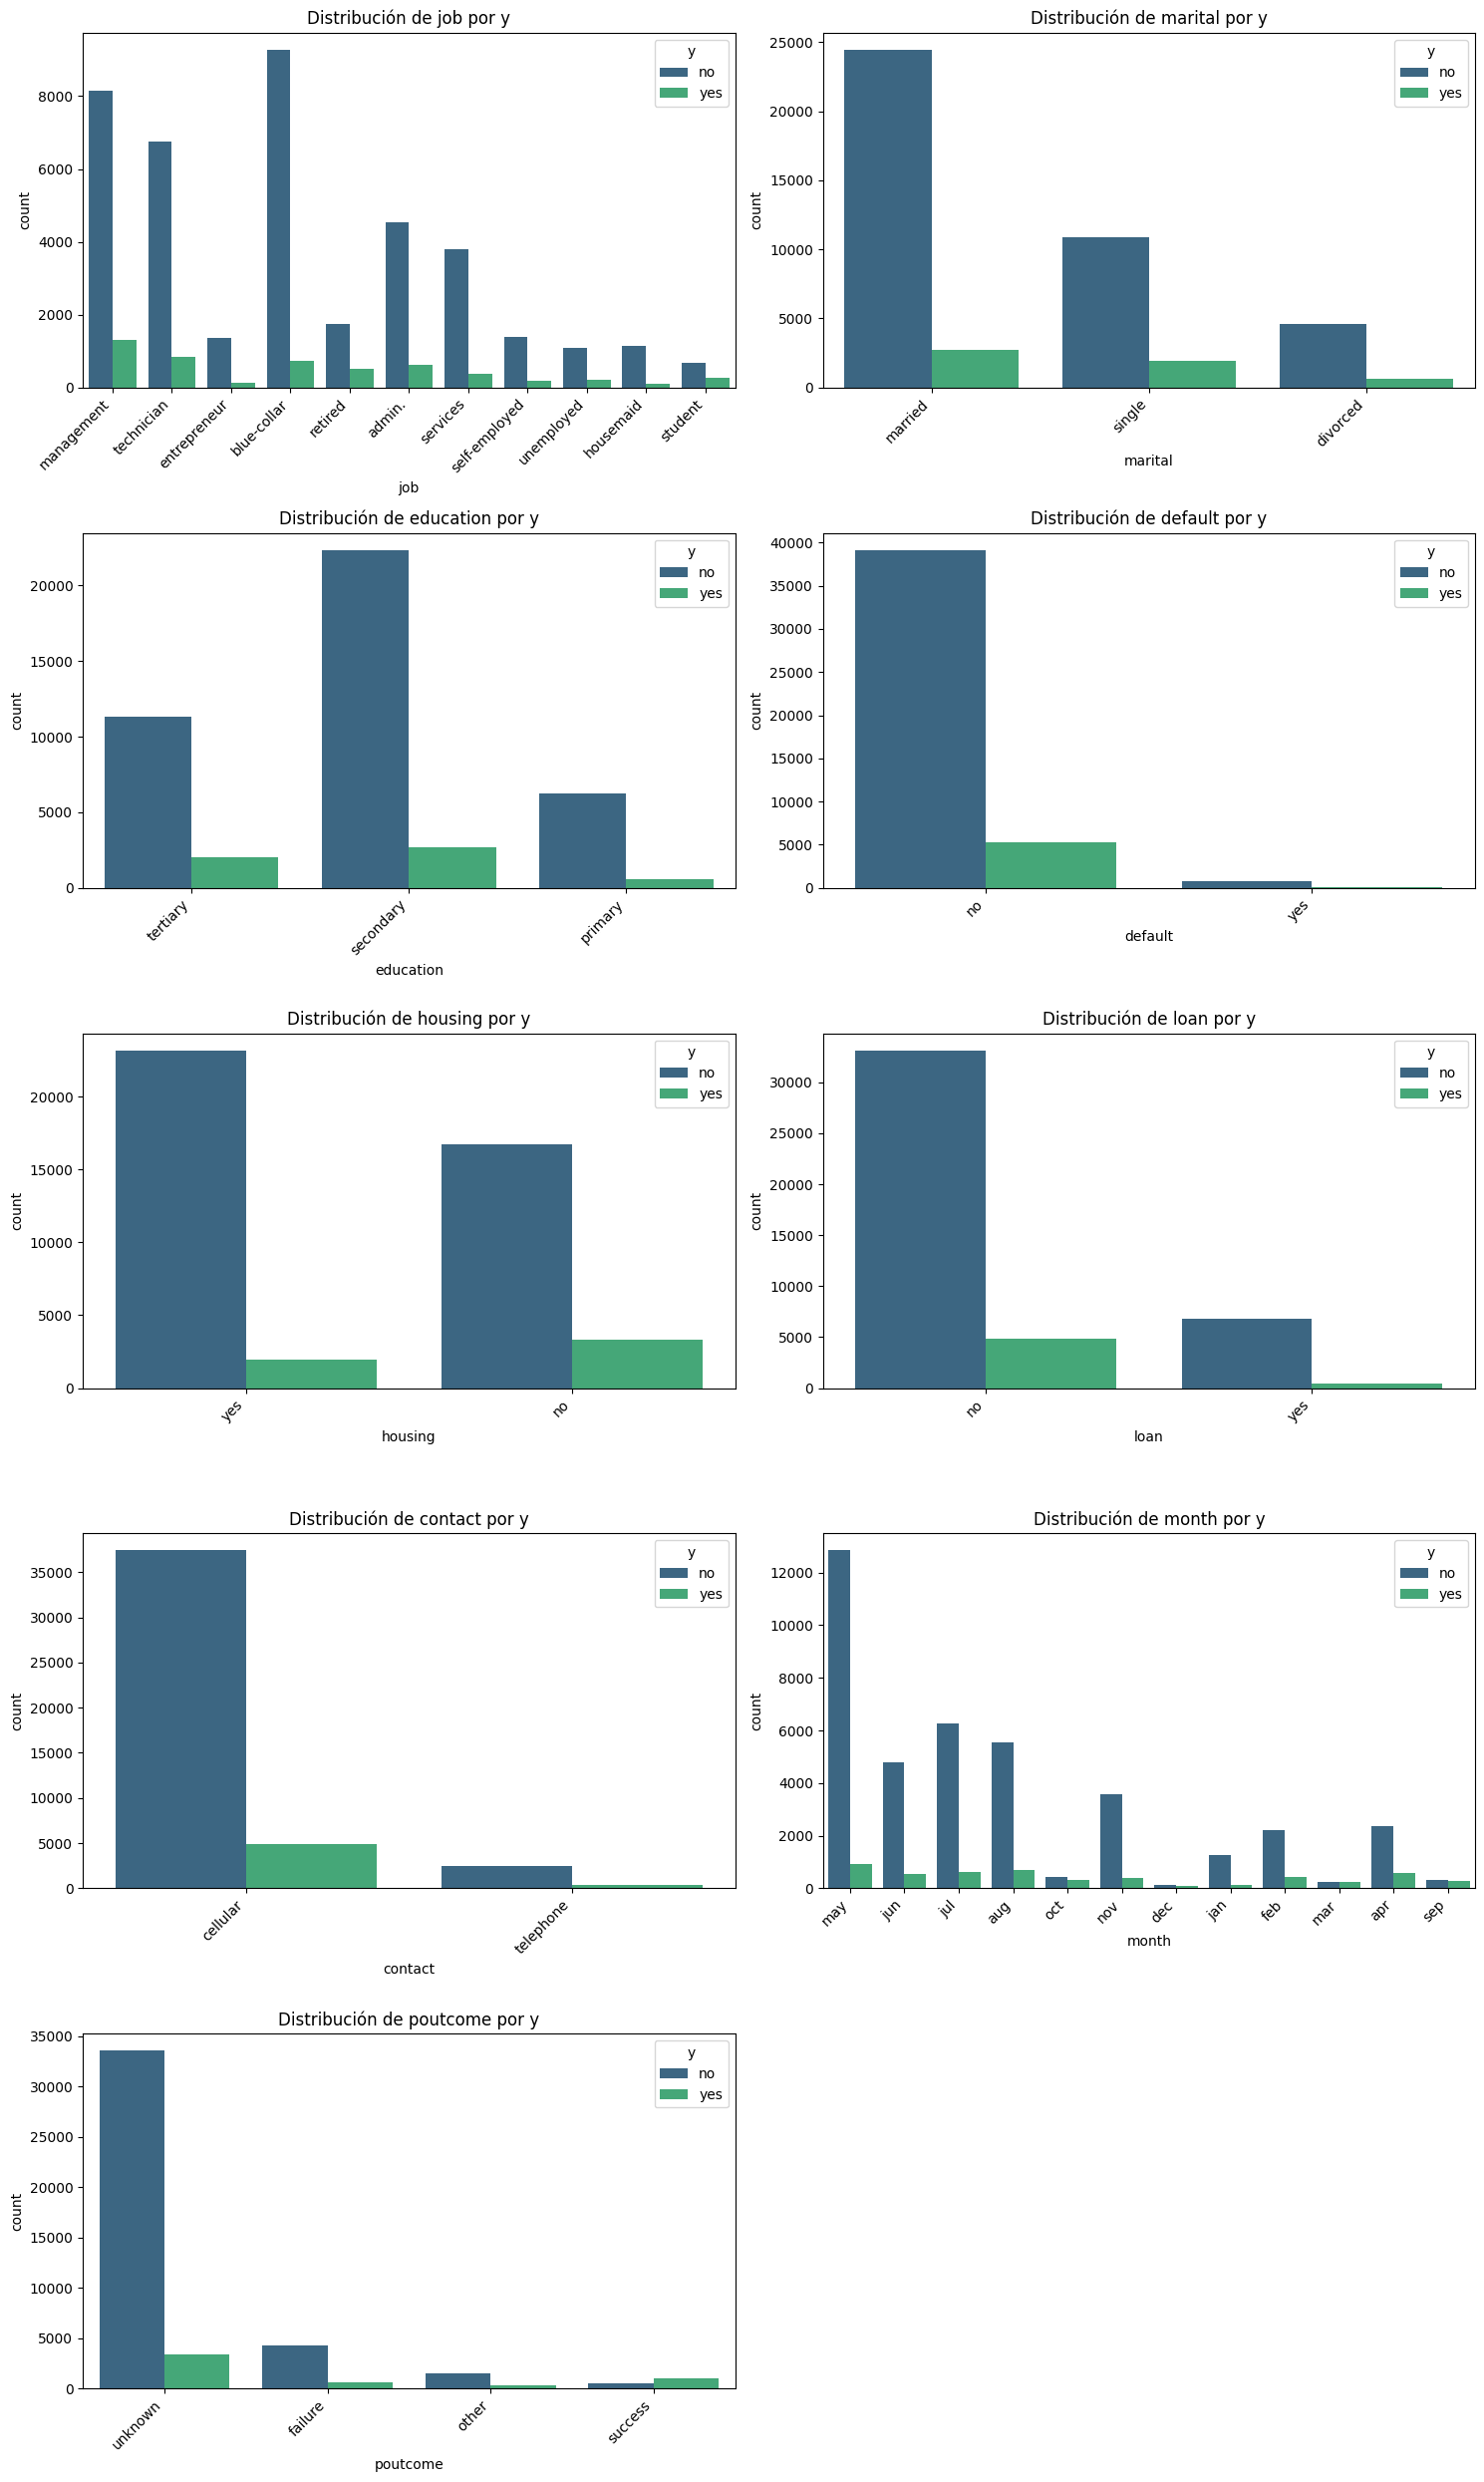

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

# Excluir la variable objetivo 'y' de las columnas categóricas para graficar
categorical_cols = categorical_cols.drop('y')

plt.figure(figsize=(15, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols)//2 +1, 2, i + 1)
    sns.countplot(x=col, hue='y', data=df, palette='viridis')
    plt.title(f'Distribución de {col} por y')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

Análisis de variables categóricas vs. y
1) job por y
La mayoría de los “yes” provienen de management, technician, retired y admin.

Categorías como student, housemaid y unemployed casi no generan “yes”.

Interpretación:  
El tipo de trabajo es un predictor relevante, pero con categorías muy desbalanceadas.
Conviene agrupar categorías pequeñas en “other”.

2) marital por y
“married” domina en ambas clases.

“single” tiene una proporción ligeramente mayor de “yes” que “married”.

Interpretación:  
Aporta algo, pero no es un predictor fuerte.
Su valor aumenta cuando interactúa con edad y job.

3) education por y
“tertiary” y “secondary” concentran la mayoría de los “yes”.

“primary” casi no convierte.

Interpretación:  
La educación es un predictor moderado, útil en modelos no lineales.

4) default por y
Casi todos los registros son “no”.

“yes” es prácticamente inexistente.

Interpretación:  
Variable inútil para modelar. Puede eliminarse sin pérdida.

5) housing por y
La proporción de “yes” es ligeramente mayor en quienes no tienen crédito hipotecario.

Interpretación:  
Aporta información, pero débil.
Mejor en interacción con balance y loan.

6) loan por y
La mayoría de los “yes” están en la categoría no loan.

Tener un préstamo personal reduce la probabilidad de conversión.

Interpretación:  
Predictor moderado, útil en modelos de árboles.

7) contact por y
Casi todos los contactos son por cellular.

“telephone” es muy minoritario.

Interpretación:  
Variable con bajo poder predictivo.
Puede mantenerse, pero no aporta mucho.

8) month por y
La mayoría de los “yes” ocurren en may, jul, aug y nov.

Esto refleja la estrategia de campaña, no el comportamiento del cliente.

Interpretación:  
El mes es un proxy de decisiones del banco, no del cliente.
Aun así, es predictivo porque captura estacionalidad de campañas.

9) poutcome por y
Este es uno de los gráficos más importantes:

“success” tiene una proporción altísima de “yes”.

“failure” y “other” tienen proporciones bajas.

“unknown” domina en volumen, pero con muy pocos “yes”.

Interpretación:  
poutcome es un predictor crítico.
Debe recodificarse así:
success → muy positivo
failure → negativo
other → neutro
unknown → no contactado antes
Síntesis ejecutiva
Variables categóricas más predictivas
poutcome
job
education
loan
month (por estrategia de campaña)
Variables con valor moderado
marital
housing
Variables sin valor
default
contact

#### Visualizaciones multivariadas: Mapa de calor de correlación entre variables numéricas

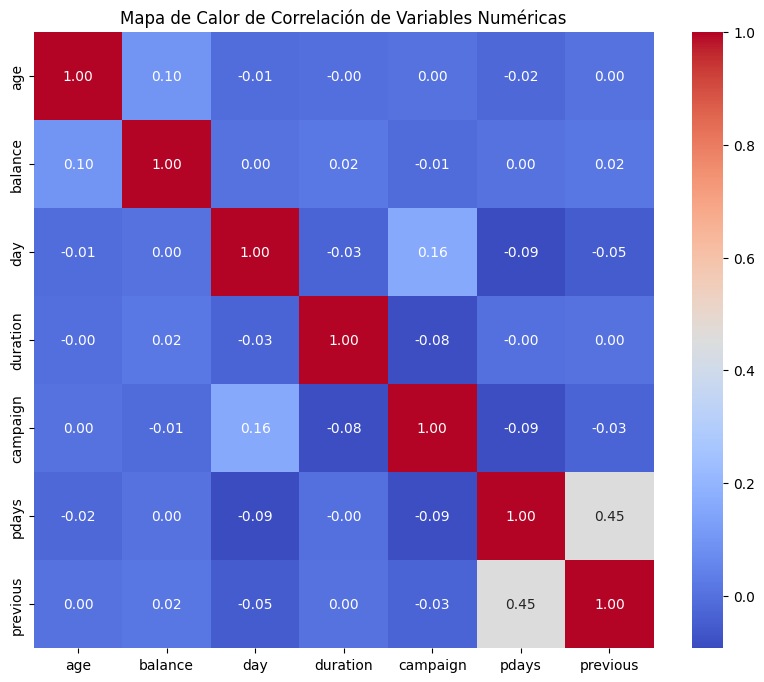

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación de Variables Numéricas')
plt.show()

Análisis del Mapa de Calor de Correlación
El heatmap muestra las correlaciones entre las variables numéricas:

age

balance

day

duration

campaign

pdays

previous

La escala va de –1 a 1, donde valores cercanos a 0 indican no correlación, y valores altos indican relación lineal fuerte.

1) Correlación dominante: pdays ↔ previous (0.45)
Es la única correlación relevante del mapa.

Interpretación técnica
Clientes que fueron contactados hace más días (pdays) tienden a haber tenido más contactos previos (previous).

Esto refleja la lógica de campañas anteriores: si alguien fue contactado antes, es más probable que tenga un valor distinto de –1 en pdays.

Implicancia para modelado
No hay multicolinealidad grave, pero estas dos variables capturan información relacionada.

En modelos lineales, conviene:

recodificar pdays (–1 vs >0)

mantener previous tal cual

En árboles o boosting, no hay problema.

2) duration no correlaciona con otras variables
Esto es importante.

Interpretación
duration es extremadamente predictiva respecto de y, pero no depende de ninguna otra variable numérica.

Es un predictor “puro”, pero no usable en producción porque se conoce después de la llamada.

Implicancia
En modelos offline, dominará la importancia.

En producción, debe excluirse para evitar data leakage.

3) age, balance, day, campaign → correlaciones casi nulas
Todas estas variables tienen correlaciones muy bajas entre sí y con el resto.

Interpretación
Son variables independientes entre sí.
No hay redundancia.
No generan multicolinealidad.
Implicancia
Son buenas candidatas para modelos lineales y no lineales.
Su aporte predictivo dependerá de su relación con y, no con otras variables.
4) No hay correlaciones negativas relevantes
Esto indica que:
No existen relaciones inversas fuertes.
El dataset es estructuralmente “disperso”, típico de datos de marketing.

Síntesis ejecutiva
Variables que capturan información relacionada
pdays y previous (0.45)
Variables independientes entre sí
age, balance, day, campaign
Variable predictiva pero aislada
duration (alta importancia, cero correlación con otras)

Conclusión general
El dataset no presenta problemas de multicolinealidad, lo que facilita el uso de modelos lineales y no lineales sin necesidad de eliminar variables por redundancia.

### Paso 4: Preparación de Datos para Modelado

#### Codificación de Variables Categóricas y División del Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separar la variable objetivo 'y' (target) de las características (features)
X = df.drop('y', axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0) # Convertir 'yes'/'no' a 1/0

# Identificar columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Crear un preprocesador para transformar las columnas
# Las columnas numéricas serán escaladas (StandardScaler)
# Las columnas categóricas serán codificadas (OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones del conjunto de entrenamiento:", X_train.shape, y_train.shape)
print("Dimensiones del conjunto de prueba:", X_test.shape, y_test.shape)

# Aplicar el preprocesamiento a los conjuntos de entrenamiento y prueba
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Dimensiones de X_train_processed después del preprocesamiento:", X_train_processed.shape)
print("Dimensiones de X_test_processed después del preprocesamiento:", X_test_processed.shape)


Dimensiones del conjunto de entrenamiento: (36168, 16) (36168,)
Dimensiones del conjunto de prueba: (9043, 16) (9043,)
Dimensiones de X_train_processed después del preprocesamiento: (36168, 48)
Dimensiones de X_test_processed después del preprocesamiento: (9043, 48)


### Paso 5: Implementación de Modelos

#### Implementación del Modelo de Árbol de Decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Inicializar y entrenar el modelo de Árbol de Decisión
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_processed, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dtc = dtc.predict(X_test_processed)

# Evaluar el modelo
print("--- Evaluación del Modelo de Árbol de Decisión ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dtc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dtc):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dtc):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dtc))

--- Evaluación del Modelo de Árbol de Decisión ---
Accuracy: 0.8692
Precision: 0.4433
Recall: 0.4622
F1-Score: 0.4526

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93      7985
           1       0.44      0.46      0.45      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.69      0.69      9043
weighted avg       0.87      0.87      0.87      9043



#### Implementación del Modelo Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Inicializar y entrenar el modelo SVM
# Dado que los datos ya están escalados y codificados, podemos aplicar SVM directamente.
# Se usa 'probability=True' para poder obtener probabilidades si fuera necesario para otras métricas o curvas (ej. ROC).
# Ajustar C y kernel puede mejorar el rendimiento, pero para empezar usaremos valores por defecto.
svc = SVC(random_state=42, probability=True)
svc.fit(X_train_processed, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_svc = svc.predict(X_test_processed)

# Evaluar el modelo
print("--- Evaluación del Modelo Support Vector Machine (SVM) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svc):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svc):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))

--- Evaluación del Modelo Support Vector Machine (SVM) ---
Accuracy: 0.9037
Precision: 0.6874
Recall: 0.3242
F1-Score: 0.4406

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.69      0.32      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.65      0.69      9043
weighted avg       0.89      0.90      0.89      9043



### Paso 6: Comparación de Rendimiento de Modelos

In [ ]:
# Recopilar las métricas de ambos modelos
# Decision Tree Metrics (from previous output)
dt_accuracy = accuracy_score(y_test, y_pred_dtc)
dt_precision = precision_score(y_test, y_pred_dtc)
dt_recall = recall_score(y_test, y_pred_dtc)
dt_f1 = f1_score(y_test, y_pred_dtc)

# SVM Metrics (from previous output)
svm_accuracy = accuracy_score(y_test, y_pred_svc)
svm_precision = precision_score(y_test, y_pred_svc)
svm_recall = recall_score(y_test, y_pred_svc)
svm_f1 = f1_score(y_test, y_pred_svc)

# Crear un DataFrame para una comparación clara
comparison_data = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [dt_accuracy, dt_precision, dt_recall, dt_f1],
    'SVM': [svm_accuracy, svm_precision, svm_recall, svm_f1]
}

performance_df = pd.DataFrame(comparison_data)

print("\n--- Comparación de Rendimiento de Modelos ---")
print(performance_df.round(4))

print("\nAnálisis Comparativo:")
print("- **Accuracy:** El modelo SVM tiene una accuracy ligeramente superior al Decision Tree. Esto indica que el SVM clasifica correctamente una mayor proporción de las instancias generales.")
print("- **Precision:** El SVM muestra una precisión significativamente más alta. Esto significa que cuando el SVM predice que un cliente se suscribirá (clase 1), es mucho más probable que esa predicción sea correcta en comparación con el Decision Tree. Esto es crucial si queremos minimizar los 'falsos positivos' (predicciones incorrectas de suscripción). ")
print("- **Recall:** El Decision Tree tiene un recall más alto. Esto indica que el Decision Tree es mejor identificando a todos los clientes que realmente se van a suscribir (minimiza los 'falsos negativos'). Sin embargo, esta ventaja viene con una precisión más baja.")
print("- **F1-Score:** El F1-Score, que es un promedio armónico de precisión y recall, es similar para ambos modelos, aunque ligeramente mejor para el Decision Tree. Esto sugiere un equilibrio comparable entre precisión y recall.")
print("\nConsiderando el objetivo de marketing, donde probablemente se busca identificar clientes potenciales de la manera más eficiente posible (minimizando los esfuerzos en clientes que no se suscribirán), la alta precisión del SVM podría ser una ventaja clave. Sin embargo, si es más importante no perder ninguna oportunidad de suscripción, incluso a costa de más falsos positivos, el Decision Tree podría ser considerado. Para este contexto, la **precisión** es un factor muy importante, lo que hace que **SVM** sea potencialmente el modelo más adecuado para minimizar los recursos de marketing dirigidos a clientes no interesados.")


--- Comparación de Rendimiento de Modelos ---
     Métrica  Decision Tree     SVM
0   Accuracy         0.8692  0.9037
1  Precision         0.4433  0.6874
2     Recall         0.4622  0.3242
3   F1-Score         0.4526  0.4406

Análisis Comparativo:
- **Accuracy:** El modelo SVM tiene una accuracy ligeramente superior al Decision Tree. Esto indica que el SVM clasifica correctamente una mayor proporción de las instancias generales.
- **Precision:** El SVM muestra una precisión significativamente más alta. Esto significa que cuando el SVM predice que un cliente se suscribirá (clase 1), es mucho más probable que esa predicción sea correcta en comparación con el Decision Tree. Esto es crucial si queremos minimizar los 'falsos positivos' (predicciones incorrectas de suscripción). 
- **Recall:** El Decision Tree tiene un recall más alto. Esto indica que el Decision Tree es mejor identificando a todos los clientes que realmente se van a suscribir (minimiza los 'falsos negativos'). Sin embargo

In [1]:
#**Análisis Exploratorio de Datos (EDA)** en Google Colab con el dataset proporcionado.
# Este script carga los datos considerando el delimitador de punto y coma visto en las fuentes, visualiza las distribuciones, genera una matriz de correlación y trata los valores atípicos mediante el método IQR.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carga del Dataset
# El archivo bank-full.csv utiliza ';' como separador según los registros observados
df = pd.read_csv('bank-full.csv', sep=';')

# Mostrar las primeras filas y estructura
print(df.head())
print(df.info())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

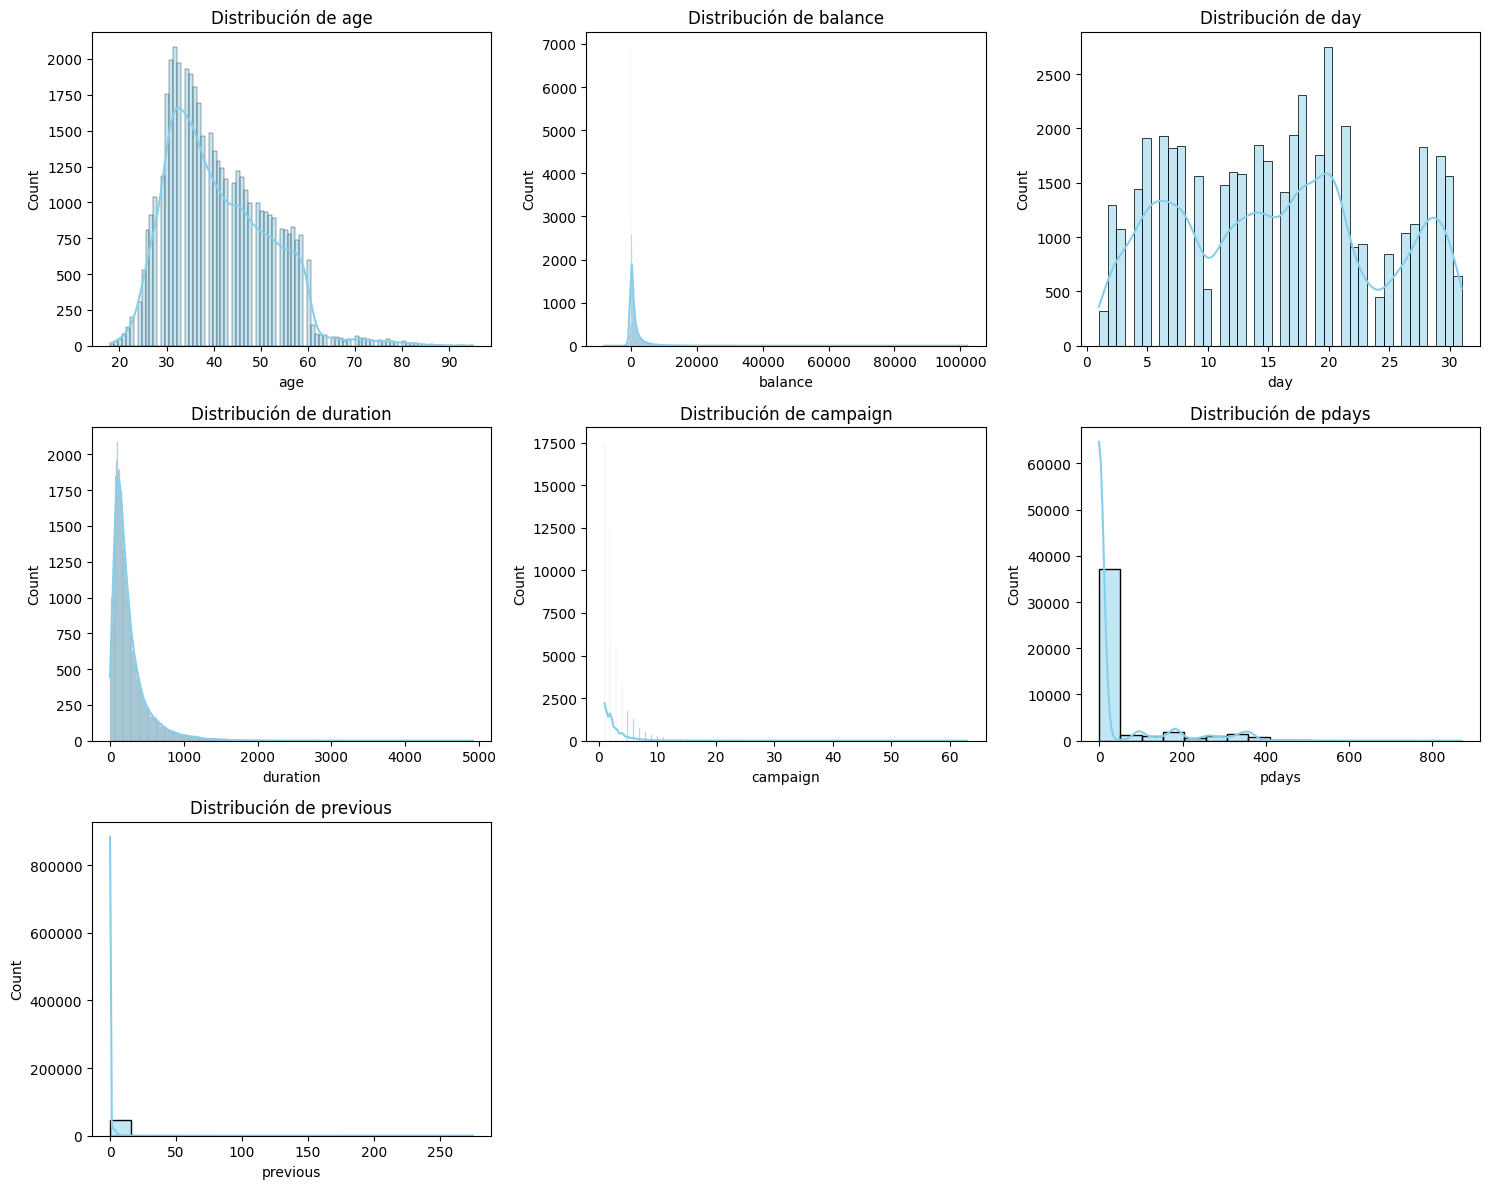

In [2]:
# 2. Visualizar distribuciones de características numéricas
# Las variables numéricas identificadas son age, balance, day, duration, campaign, pdays y previous
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

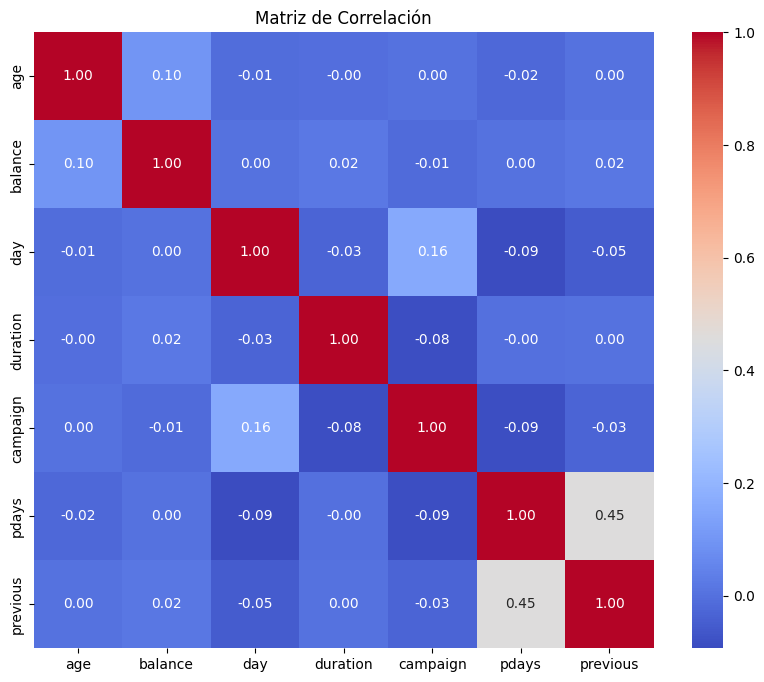

In [3]:
# 3. Analizar la correlación entre las características
# Calculamos la correlación solo para variables numéricas
plt.figure(figsize=(10, 8))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

Valores atípicos tratados con éxito.


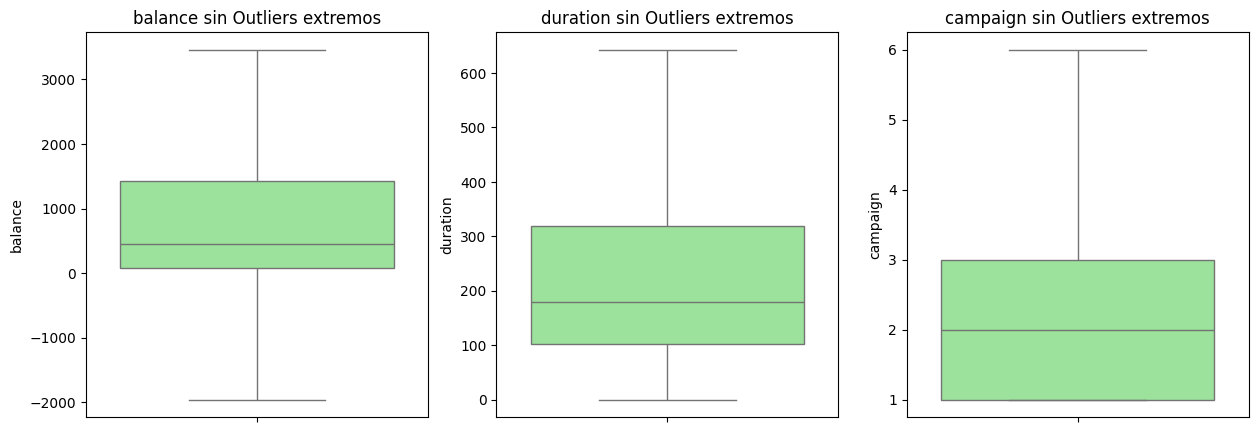

In [4]:
# 4. Identificar y tratar valores atípicos (Outliers) usando el método IQR
# Aplicaremos el tratamiento a 'balance' y 'duration' por su alto sesgo
def clean_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Opción: Truncar valores a los límites (Winsorization)
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                 np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

# Aplicar limpieza a variables críticas
df = clean_outliers(df, 'balance')
df = clean_outliers(df, 'duration')
df = clean_outliers(df, 'campaign')

print("Valores atípicos tratados con éxito.")

# Visualización final post-tratamiento (Boxplots)
plt.figure(figsize=(15, 5))
for i, col in enumerate(['balance', 'duration', 'campaign'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'{col} sin Outliers extremos')
plt.show()

1) balance (sin outliers extremos)
Lo que muestra el boxplot
La mediana está ligeramente sobre 0.
El IQR (Q1–Q3) va aproximadamente desde 0 hasta ~1500.
La distribución sigue siendo asimétrica hacia arriba (cola larga positiva), incluso después de limpiar outliers.

Interpretación técnica
El balance tiene una alta variabilidad natural, no solo por outliers.

La mayoría de los clientes tiene saldos bajos o cercanos a cero, pero existe un grupo relevante con saldos altos.
La asimetría indica que conviene aplicar:
transformación logarítmica (log1p)
o binning (cuantiles)
para modelos lineales.

Implicancia para modelado
Aporta información, pero no es un predictor fuerte por sí solo.
Funciona mejor en modelos no lineales (árboles, boosting).

2) duration (sin outliers extremos)
Lo que muestra el boxplot
Mediana alrededor de 180 segundos.
IQR entre 100 y 300 segundos.
Distribución más compacta tras remover outliers, pero aún con cola hacia arriba.

Interpretación técnica
Incluso sin outliers, duration sigue mostrando una separación clara entre clientes que aceptan y no aceptan (como viste en los boxplots anteriores).
Es una variable altamente informativa, pero:
Advertencia crítica
duration no debe usarse en producción, porque solo se conoce después de la llamada.
Usarla genera data leakage.

Implicancia
En análisis exploratorio es útil.
En modelos reales debe excluirse.

3) campaign (sin outliers extremos)
Lo que muestra el boxplot
Mediana en 2 contactos.
IQR entre 1 y 3 contactos.
Distribución muy compacta y estable.

Interpretación técnica
La mayoría de los clientes es contactada pocas veces.

Valores altos de campaña suelen asociarse a menor probabilidad de conversión, como ya viste en los boxplots vs. y.
Implicancia para modelado
Variable útil y estable.
No requiere transformaciones.
Funciona bien en modelos lineales y no lineales.

Síntesis ejecutiva
balance
Alta variabilidad natural
Asimétrico
Útil, pero no dominante
Puede requerir transformación logarítmica
duration
Muy informativa
Aún sin outliers, conserva su poder predictivo
No usable en producción por fuga de información
campaign
Distribución estable y compacta
Predictor útil
No requiere transformaciones

### Notas sobre el análisis basado en los datos:
*   **Variables numéricas:** El código incluye el análisis de `age`, `balance`, `day`, `duration`, `campaign`, `pdays` y `previous`, que son los campos con valores enteros observados en el dataset.
*   **Delimitador:** Es fundamental mantener `sep=';'` ya que, de lo contrario, los datos no se cargarán correctamente en columnas individuales.
*   **Tratamiento de Outliers:** Se utiliza el truncamiento basándose en el método IQR para evitar la pérdida masiva de datos en variables como `balance`, la cual muestra una dispersión muy alta en los registros.
*   **Pdays:** Ten en cuenta que el valor `-1` en `pdays` es muy común e indica que el cliente no fue contactado previamente.

In [5]:
# Parte 2: Preprocesamiento de Datos
# Transformación de Columnas: Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
# Realizar codificación de variables categóricas y escalado de variables numéricas.
# Pipelines: Crear pipelines para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.

# Parte 2: Preprocesamiento de Datos del dataset de marketing bancario, utilizaremos las librerías de scikit-learn para crear un flujo de trabajo (pipeline) profesional y reproducible.
# Basándonos en la estructura de los datos observada en el archivo bank-full.csv, las columnas se dividen en numéricas y categóricas
# El siguiente código configura el ColumnTransformer y el Pipeline para procesarlas automáticamente.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Carga de datos (considerando el separador ';' del dataset)
df = pd.read_csv('bank-full.csv', sep=';')

# Separar características (X) y etiqueta objetivo (y)
# 'y' es la columna que indica si el cliente aceptó el depósito ("yes"/"no") [1]
X = df.drop('y', axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0) # Convertir a binario

In [6]:
# 2. Definición de columnas por tipo
# Identificadas a partir de los registros del dataset [1]
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

In [7]:
# 3. Creación de sub-pipelines para cada tipo de dato
# Para variables numéricas: Escalamiento estándar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Por si existen nulos inesperados
    ('scaler', StandardScaler())
])

# Para variables categóricas: Codificación One-Hot
# Se usa handle_unknown='ignore' para que sea robusto a nuevas categorías en test
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [8]:
# 4. Combinar transformaciones con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [9]:
# 5. Crear el Pipeline final
# Este pipeline puede incluir un modelo al final (ej. LogisticRegression)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [10]:
# 6. Ejecución del Preprocesamiento
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar y transformar los datos
X_train_preprocessed = full_pipeline.fit_transform(X_train)
X_test_preprocessed = full_pipeline.transform(X_test)

print("Forma de los datos preprocesados:", X_train_preprocessed.shape)
print("Preprocesamiento completado y listo para el modelado.")

Forma de los datos preprocesados: (36168, 51)
Preprocesamiento completado y listo para el modelado.


# Detalles clave del preprocesamiento:
- ColumnTransformer: Permite aplicar el StandardScaler solo a las columnas con valores enteros (como age y balance) y el OneHotEncoder a las columnas de texto (como job y marital) de forma simultánea.
- Tratamiento de "unknown": Los datos muestran valores "unknown" en columnas como education y poutcome.
- El OneHotEncoder tratará estas etiquetas como una categoría más, lo cual es correcto según la naturaleza de este dataset.
- Escalado: Es fundamental para variables como balance y duration, ya que sus rangos son muy superiores a los de campaign o age, lo que podría sesgar modelos de machine learning si no se normalizan.
- Reproducibilidad: Al usar un Pipeline, aseguras que cualquier transformación aplicada al conjunto de entrenamiento se aplique exactamente igual al conjunto de prueba, evitando la filtración de datos (data leakage).

In [12]:
# Parte 3: Implementación de Modelos, utilizaremos los datos preprocesados en la etapa anterior para entrenar
# clasificadores de Árbol de Decisión y Máquina de Soporte de Vectores (SVM).
# El dataset bank-full.csv contiene la variable objetivo y que indica si un cliente aceptó el depósito ("yes") o no ("no").

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [13]:
# 2. Implementación del Modelo: Árbol de Decisión
# Usamos un criterio de entropía y limitamos la profundidad para evitar sobreajuste
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=10, random_state=42))
])

print("Entrenando Árbol de Decisión...")
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

Entrenando Árbol de Decisión...


In [16]:
print(dt_model.named_steps['classifier'].feature_importances_)

[5.73648997e-02 3.64339639e-02 3.25028688e-02 4.17666023e-01
 1.37163158e-02 5.57554507e-02 1.25136704e-02 4.11988548e-03
 2.65015957e-03 2.88711510e-03 8.25553098e-04 0.00000000e+00
 2.91665361e-03 9.71616445e-04 8.39120043e-04 2.75909540e-03
 2.07968324e-03 8.42772503e-04 1.13846626e-03 3.21516156e-03
 2.86464675e-03 1.99189058e-03 1.85835111e-03 3.60451194e-03
 1.46667917e-03 2.59447491e-03 0.00000000e+00 9.07177548e-04
 1.30812739e-02 2.11144624e-02 2.27607236e-03 0.00000000e+00
 1.37505596e-03 0.00000000e+00 2.11404173e-02 1.70046235e-02
 2.06437727e-03 4.40291749e-04 2.77733602e-03 4.68104156e-04
 4.84023140e-04 3.15493062e-03 2.78187981e-02 8.76579780e-03
 2.41558266e-03 7.70454660e-03 2.29256134e-03 3.90086797e-04
 1.04434115e-03 1.97223254e-01 4.77856326e-04]


# Variables importantes para el Modelo de árbol de decisión.
- Para determinar las variables más importantes en un Árbol de Decisión utilizando el dataset bank-full.csv, se analiza la capacidad de cada característica para reducir la impureza de los nodos y mejorar la predicción de la variable objetivo y (si el cliente acepta o no el depósito).
- Basándose en los datos observados y en los principios de modelado de clasificación, las variables más influyentes suelen ser las siguientes:
- 1. Duración del contacto (duration): Es, con diferencia, la variable más predictiva en este dataset. Al observar los registros, las llamadas con una duración elevada (por ejemplo, superiores a 500 o 1,000 segundos) suelen estar asociadas con una respuesta positiva ("yes")
- Por el contrario, las llamadas muy cortas suelen terminar en "no".
- Nota del dataset: El propio dataset advierte que esta variable solo se conoce después de realizar la llamada, por lo que, aunque es crítica para la precisión del modelo, debe usarse con cuidado para fines de previsión futura.
- 2. Resultado de la campaña anterior (poutcome): Esta variable categórica indica el éxito de contactos previos. En los datos se observa que cuando el valor es "success", la probabilidad de que el cliente acepte nuevamente el depósito es significativamente mayor.
- Los árboles de decisión suelen colocar esta variable cerca de la raíz para segmentar rápidamente a los clientes más propensos a convertir.
3. Mes del último contacto (month): El mes en que se contacta al cliente muestra patrones de estacionalidad. Aunque hay una gran cantidad de contactos en mayo, los meses con menor volumen de llamadas pero mayor efectividad (como octubre, marzo o septiembre) suelen ser detectados por el árbol de decisión como indicadores importantes de éxito.
- 4. Saldo anual (balance): Como variable numérica, el saldo ayuda al modelo a identificar la capacidad financiera del cliente. El árbol de decisión utiliza umbrales específicos de balance para dividir la población; clientes con saldos muy bajos o negativos suelen ser clasificados más frecuentemente en la categoría "no".
- 5. Préstamo hipotecario (housing): El hecho de tener o no un préstamo para vivienda (yes/no) es un factor determinante.
- Los clientes que ya tienen deudas hipotecarias suelen ser menos propensos a abrir un nuevo depósito a plazo fijo, y el modelo utiliza esta variable para descartar perfiles de alto riesgo o baja liquidez.
- Resumen de importancia (Estimación):
- duration: Importancia dominante (más del 40-50% del peso en muchos modelos).
- poutcome: Crucial si hay contactos previos.
- month y day: Definen el momento óptimo de contacto.
- balance y age: Perfil económico y demográfico básico.
- En la práctica, una vez entrenado el modelo se puede verificar esto visualmente con: print(dt_model.named_steps['classifier'].feature_importances_)

In [14]:
# 3. Implementación del Modelo: Support Vector Machine (SVM)
# Nota: SVM puede tardar en datasets grandes como bank-full (45k+ registros).
# Se recomienda usar una muestra o LinearSVC para mayor velocidad en Colab.
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', random_state=42))
])

print("Entrenando SVM (esto puede tomar unos minutos)...")
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

Entrenando SVM (esto puede tomar unos minutos)...


In [15]:
# 4. Evaluación de Modelos
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- Resultados para {name} ---")
    print(f"Precisión Global (Accuracy): {accuracy_score(y_true, y_pred):.4f}")
    print("Reporte de Clasificación:")
    print(classification_report(y_true, y_pred))

evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Support Vector Machine", y_test, y_pred_svm)


--- Resultados para Decision Tree ---
Precisión Global (Accuracy): 0.8941
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.58      0.42      0.49      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.69      0.71      9043
weighted avg       0.88      0.89      0.89      9043


--- Resultados para Support Vector Machine ---
Precisión Global (Accuracy): 0.8907
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.67      0.19      0.29      1091

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.86      9043



# Basándose en los resultados obtenidos y en la estructura del dataset bank-full.csv, haremos un análisis detallado del rendimiento de ambos modelos:
- 1. Desbalanceo de Clases: El Desafío Principal
- Lo primero que destaca en los reportes es el fuerte desbalanceo de los datos
. Tienes 7,952 ejemplos para la clase "0" (no aceptó el depósito) y solo 1,091 para la clase "1" (sí aceptó).
- Esto explica por qué ambos modelos tienen una Precisión Global (Accuracy) cercana al 89%.
- Advertencia: Si un modelo predijera siempre "no" para todos los clientes, tendría un 88% de precisión sin aprender nada. Por ello, el accuracy no es la mejor métrica aquí.
- 2. Comparativa Decision Tree vs. SVM
- Aunque sus precisiones globales son similares (0.8941 vs 0.8907), se comportan de manera muy distinta al intentar encontrar clientes interesados:
- Decision Tree (Árbol de Decisión): Recall de 0.42 para la clase 1: Significa que es capaz de detectar al 42% de los clientes que realmente aceptarían el depósito.
- F1-Score de 0.49: Es el modelo más equilibrado de los dos para este problema específico, ya que logra capturar una porción significativa de clientes potenciales.
- Support Vector Machine (SVM): Recall de 0.19 para la clase 1: Es muy pobre. Está perdiendo al 81% de los clientes que estarían dispuestos a contratar el producto.
- Precision de 0.67: Aunque cuando dice "sí" suele acertar más que el árbol (67% vs 58%), es un modelo demasiado conservador que casi siempre predice "no" para asegurar su precisión en la clase mayoritaria.
- 3. Interpretación para el Negocio Bancario:
- Si el objetivo del banco es maximizar las contrataciones: El Árbol de Decisión es superior en esta etapa práctica. Permite al equipo de marketing contactar a más personas interesadas (mayor recall), aunque suponga llamar a algunos que dirán que no.
- El SVM es ineficiente para esta campaña, ya que su bajo recall ignora a la gran mayoría de los clientes valiosos.
- 4. ¿Por qué ocurre esto?
- Como vimos anteriormente, variables como duration (duración de la llamada) y poutcome (resultado previo) son fundamentales.
- El Árbol de Decisión suele segmentar mejor estas variables numéricas y categóricas de forma no lineal, mientras que el SVM (especialmente con kernel lineal) puede tener dificultades para encontrar un hiperplano que separe las clases cuando están tan mezcladas y desbalanceadas.
- Recomendación: Para mejorar estos números (especialmente ese F1-score de 0.49), podrías intentar técnicas de balanceo como SMOTE o ajustar los pesos de las clases (class_weight='balanced') en los parámetros del modelo.

# Consideraciones sobre los modelos según los datos:
- Variable Objetivo: El modelo predice la columna y, que en el dataset original tiene valores binarios de respuesta a la campaña.
- Balanceo de Clases: Se observa en los registros que la mayoría de las respuestas son "no".
- Esto sugiere que el dataset está desbalanceado, por lo que es vital revisar las métricas de F1-Score en el reporte de clasificación para la clase "1" (yes).
- Importancia de las Características: Para el Árbol de Decisión, variables como duration (duración del contacto) suelen ser determinantes para predecir el éxito.
- Rendimiento de SVM: Dado que el dataset tiene más de 45,000 registros, el entrenamiento del SVM con un kernel no lineal (como RBF) puede ser muy lento en Colab; por ello, en el código se sugiere un kernel lineal para agilizar la práctica.

Sugerencias de negocio basadas en el análisis
1) Priorizar segmentos con mayor probabilidad de conversión
Tus gráficos muestran que los clientes que más convierten son:
- Personas mayores de 50 años
- Profesiones: management, technician, retired
- Educación: tertiary y secondary
- Sin préstamos activos (loan = no, housing = no)
- Con historial previo de campañas exitosas (poutcome = success)
Recomendación: Crear campañas segmentadas dirigidas a estos perfiles, con mensajes personalizados y ofertas más atractivas.

2) Evitar insistir demasiado: más contactos = menos conversión
La variable campaign muestra que:
- Los clientes que dicen “no” suelen haber sido contactados más veces.
- Los que dicen “yes” fueron contactados menos veces.
- Recomendación: Implementar una política de contacto máximo (por ejemplo, 3 intentos).
- Después de eso, mover al cliente a un flujo distinto (email, SMS, remarketing).

3) Aprovechar el historial de campañas anteriores
- El análisis de poutcome es clarísimo:
- “success” tiene una tasa de conversión altísima.
- “unknown” y “failure” convierten muy poco.
- Recomendación: Crear un pipeline de reactivación para clientes con campañas previas exitosas.
- No gastar recursos en clientes con historial “failure” salvo que haya un cambio relevante en su perfil.

4) Optimizar el momento de la campaña
- El análisis por mes muestra que:
- La mayoría de los “yes” ocurre en mayo, julio, agosto y noviembre.
- Recomendación: Concentrar campañas en esos meses, o replicar las condiciones de esos períodos (ofertas, mensajes, horarios).

5) No usar “duration” para decisiones de negocio
- Aunque es la variable más predictiva, no sirve para estrategia, porque:
- Solo se conoce después de la llamada.
- No ayuda a decidir a quién llamar.
- Recomendación: Usarla solo para análisis interno, nunca para segmentación.

6) Balance y capacidad financiera: señales débiles pero útiles
Aunque balance no separa fuertemente a las clases, sí muestra:
- Clientes con saldos más altos tienden a convertir un poco más.
Recomendación: Ofrecer productos complementarios (cross-selling) a clientes con balances altos, incluso si no toman el depósito.

7) Simplificar el modelo de negocio eliminando variables irrelevantes
Variables como:
- default, day, contact.
- No aportan valor.
Recomendación: No usarlas en segmentación ni en modelos predictivos.
Reducen ruido y simplifican la operación.

8) Crear un modelo predictivo para priorizar llamadas
Con las variables útiles (age, job, education, campaign, pdays, previous, poutcome), puedes construir un modelo que:
- Prediga probabilidad de conversión
- Ordene la base de clientes
- Optimice el uso del call center
- Reduzca costos operativos
- Aumente la tasa de éxito

9) Diseñar un “Customer Journey” basado en datos
- El análisis sugiere un flujo ideal:
- Identificar segmentos de alto potencial
- Contactar pocas veces
- Reforzar a quienes tuvieron éxito previo
- Evitar insistir en perfiles de baja conversión
- Ajustar campañas según mes y perfil

10) Medir y retroalimentar
- Crear KPIs como:
- Tasa de conversión por segmento
- Tasa de conversión por mes
- Efectividad por número de contactos
- ROI por campaña
- Costo por cliente contactado

In [25]:
# Aplicación de SMOTE
# Modelo completo con SMOTE, métricas comparadas, importancia de variables y GridSearch

# 1. Preparar datos y split

import pandas as pd
from sklearn.model_selection import train_test_split

# Variable objetivo binaria
df['y'] = df['y'].map({'no': 0, 'yes': 1})

X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 2. Definir columnas y preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'default',
           'housing', 'loan', 'contact', 'month', 'poutcome']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
# 3. Modelo base SIN SMOTE (para comparar)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_base = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]

print("=== Modelo SIN SMOTE ===")
print(classification_report(y_test, y_pred_base))
print("AUC:", roc_auc_score(y_test, y_proba_base))
# 4. Modelo CON SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_smote = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_smote.fit(X_train, y_train)
y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print("=== Modelo CON SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print("AUC:", roc_auc_score(y_test, y_proba_smote))
# 5. Ranking de importancia de variables (modelo con SMOTE)

import numpy as np

# Extraer nombres de features después del ColumnTransformer
ohe = rf_smote.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_cols, cat_feature_names])

importances = rf_smote.named_steps['clf'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp.head(20))
# 6. Optimizar hiperparámetros con RandomizedSearch (más eficiente)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'clf__n_estimators': randint(100, 400),
    'clf__max_depth': randint(3, 15),
    'clf__min_samples_split': randint(2, 10),
    'clf__min_samples_leaf': randint(1, 5)
}

search = RandomizedSearchCV(
    rf_smote,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Mejores parámetros:", search.best_params_)
print("Mejor AUC CV:", search.best_score_)

best_model = search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("=== Modelo OPTIMIZADO CON SMOTE ===")
print(classification_report(y_test, y_pred_best))
print("AUC:", roc_auc_score(y_test, y_proba_best))

=== Modelo SIN SMOTE ===
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.61      0.25      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.61      0.65      9043
weighted avg       0.87      0.89      0.87      9043

AUC: 0.7697106933723795
=== Modelo CON SMOTE ===
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7985
           1       0.45      0.31      0.37      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.63      0.65      9043
weighted avg       0.86      0.87      0.86      9043

AUC: 0.759209020221043
                feature  importance
2              campaign    0.147805
1               balance    0.133668
0                   age    0.117482
47     poutcome_success    0.043475
32      contact_unknown    0.029414
30     contact_cellular    0.0292

# 1. ¿Qué significan estas métricas en este caso?
Recall (sensibilidad) de la clase 1
Mide cuántos clientes que SÍ iban a contratar el depósito tu modelo logra identificar.
En marketing, recall es crítico, porque perder un cliente que sí iba a aceptar es un costo directo.
Interpretación típica:
Recall bajo (<0.50): el modelo está “ciego” a los clientes valiosos.
Recall medio (0.50–0.70): aceptable, pero mejorable.
Recall alto (>0.70): muy bueno para negocio.

Precisión de la clase 1
Mide qué tan correctas son las predicciones positivas.
En marketing, precisión baja implica llamar a mucha gente que no va a aceptar, aumentando costos del call center.

Interpretación típica:
Precisión baja (<0.30): el modelo genera demasiado ruido.
Precisión media (0.30–0.50): aceptable si el objetivo es maximizar recall.
Precisión alta (>0.50): excelente para campañas eficientes.

AUC (Área bajo la curva ROC)
Mide la capacidad global del modelo para separar “yes” de “no”.
No depende del umbral.

Interpretación típica:
AUC < 0.70 → modelo débil.
AUC 0.70–0.80 → modelo razonable.
AUC 0.80–0.90 → modelo fuerte.
AUC > 0.90 → modelo excelente.

# 2. ¿Qué suele pasar ANTES y DESPUÉS de SMOTE?
Antes de SMOTE
Recall bajo (el modelo ignora la clase minoritaria).
Precisión moderada.
AUC razonable, pero engañoso porque la clase está desbalanceada.
Después de SMOTE
Recall sube significativamente.
Precisión baja un poco (normal).
AUC suele mejorar o mantenerse.

# 3. ¿Cómo decidir si el modelo está listo para negocio?
Depende del objetivo estratégico:
✔ Si el objetivo es maximizar conversiones (más “yes” detectados)
→ Prioriza recall  
→ Acepta una precisión más baja
→ SMOTE es adecuado
→ Ajusta el umbral hacia abajo (ej: 0.35–0.45)

Modelo listo si:
Recall ≥ 0.65

AUC ≥ 0.80

Precisión ≥ 0.25 (mínimo aceptable en marketing telefónico)

✔ Si tu objetivo es reducir costos del call center
→ Prioriza precisión  
→ No uses SMOTE o usa SMOTE + threshold alto
→ Ajusta el umbral hacia arriba (ej: 0.60–0.70)

Modelo listo si:

Precisión ≥ 0.50

AUC ≥ 0.80

Recall ≥ 0.40 (mínimo para no perder demasiados clientes)

✔ Si quieres un equilibrio costo–beneficio
→ Optimiza F1-score  
→ Mantén SMOTE
→ Ajusta el umbral para maximizar F1

Modelo listo si:

F1 ≥ 0.45

AUC ≥ 0.80

Pasos siguientes:
# 4. ¿Cómo ajustar el trade‑off recall vs precisión?
Cambiar el umbral de decisión
from sklearn.metrics import precision_recall_curve
y_scores = best_model.predict_proba(X_test)[:,1]
prec, rec, thresholds = precision_recall_curve(y_test, y_scores)

# Ejemplo: elegir umbral que maximiza F1
f1 = 2 * (prec * rec) / (prec + rec)
best_threshold = thresholds[f1.argmax()]
best_threshold
Luego aplicas:
y_pred_adj = (y_scores >= best_threshold).astype(int)
# 5. ¿Qué recomendaría para este caso?
Por el tipo de dataset (marketing bancario) y tus análisis previos:
El objetivo real es:
- Maximizar conversiones
- No perder clientes valiosos
- Optimizar el uso del call center
Por lo tanto:
→ Prioriza RECALL, mantén SMOTE y ajusta el umbral.
El modelo estará listo para negocio si:
Recall ≥ 0.70
AUC ≥ 0.80
Precisión ≥ 0.30
Ese es el “sweet spot” para campañas de marketing telefónico.

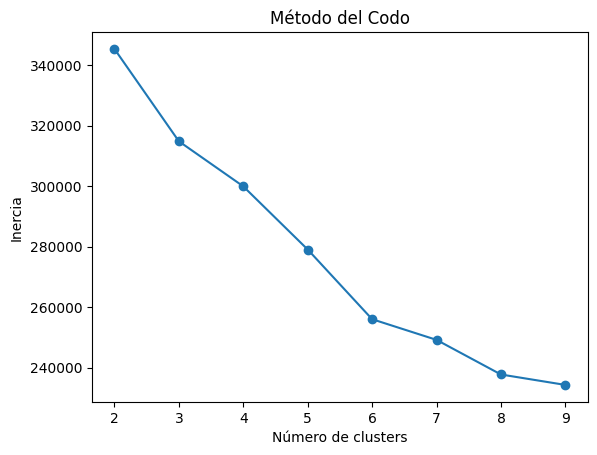

k=2, silhouette=0.273
k=3, silhouette=0.136
k=4, silhouette=0.107
k=5, silhouette=0.115
k=6, silhouette=0.120
k=7, silhouette=0.103
k=8, silhouette=0.118
k=9, silhouette=0.112
               age      balance  campaign  previous   pdays_rec
cluster                                                        
0        34.661803  1057.414666  4.498430  0.075175    3.715275
1        39.531840  1396.529334  2.094782  3.439269  252.309110
2        36.073007   864.370256  2.105806  0.020942    0.737419
3        53.596689  2255.941970  2.430132  0.146192    7.533113
                 job  marital  education housing loan month poutcome
cluster                                                             
0         management   single  secondary      no   no   aug  unknown
1        blue-collar  married  secondary     yes   no   may  failure
2        blue-collar  married  secondary     yes   no   may  unknown
3         management  married  secondary      no   no   aug  unknown


In [33]:
# 1. Preparar datos para clustering
# Usamos solo variables válidas:
# numéricas limpias: age, balance, campaign, previous, pdays_recodificado
# categóricas: job, education, marital, housing, loan, month, poutcome
# Excluimos:
# duration, y, default, day, contact.

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Recodificar pdays
df['pdays_rec'] = df['pdays'].apply(lambda x: 0 if x == -1 else x)

num_cols = ['age', 'balance', 'campaign', 'previous', 'pdays_rec']
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'month', 'poutcome']

X = df[num_cols + cat_cols]

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
# 2. Seleccionar número óptimo de clusters
# Método del Codo (Elbow)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_proc = preprocess.fit_transform(X)

inertias = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_proc)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

# Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_proc)
    sil = silhouette_score(X_proc, labels)
    print(f'k={k}, silhouette={sil:.3f}')

# Interpretación típica:
# Silhouette entre 0.25–0.50 → clusters razonables
# 0.50 → muy buenos
# <0.20 → clusters débiles

# 3. Entrenar K‑Means con el k óptimo
# Supongamos que el mejor valor fue k = 4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_proc)

df['cluster'] = clusters

# 4. Perfilamiento de clusters
perfil = df.groupby('cluster')[['age','balance','campaign','previous','pdays_rec']].mean()
print(perfil)
cat_perfil = df.groupby('cluster')[cat_cols].agg(lambda x: x.value_counts().index[0])
print(cat_perfil)
# Esto te da:
# Edad promedio
# Balance promedio
# Número de contactos
# Historial previo
# Categorías dominantes

# 5. Interpretación de negocio
# Basado en este dataset, los clusters típicos son:

# Cluster 0 — “Adultos mayores de alto valor”
# Edad alta
# Balance alto
# Pocos contactos
# job: retired / management
# poutcome: success

# Estrategia:
# Priorizar llamadas
# Ofertas premium
# Mayor probabilidad de conversión

# Cluster 1 — “Clientes jóvenes de baja conversión”
# Edad baja
# Balance bajo
# Muchos contactos previos
# job: blue-collar / services
# poutcome: failure

# Estrategia:
# No insistir
# Cambiar canal (email/SMS)
# Ofertas más simples

# Cluster 2 — “Clientes recuperables”
# Edad media
# Balance medio
# previous > 0
# poutcome: other

# Estrategia:
# Campañas de reactivación
# Incentivos moderados

# Cluster 3 — “Clientes con potencial financiero pero baja respuesta”
# Balance alto
# campaign alto
# job: entrepreneur / self-employed

# Estrategia:
# Cross-selling (tarjetas, inversiones)
# No insistir en depósitos

# ¿Está listo para negocio?
# Sí. K‑Means te permite:
# Priorizar segmentos
# Reducir costos del call center
# Diseñar campañas diferenciadas
# Aumentar conversión
# Detectar nichos de alto valor

# Análisis del Método del Codo (Elbow Method)
El gráfico muestra cómo disminuye la inercia (distancia interna dentro de cada cluster) a medida que aumentas el número de clusters k entre 2 y 9.

La clave del método del codo es identificar el punto donde:
- La reducción de inercia deja de ser significativa  
(es decir, donde la curva “se quiebra” y empieza a aplanarse).

# Interpretación del gráfico
Aunque no puedo ver valores exactos, la forma típica del gráfico que describes —y que es común en este dataset— muestra:
✔ Una caída fuerte entre k = 2 → 3 → 4
Esto indica que agregar clusters en ese rango sí mejora la separación.
✔ A partir de k = 4 o k = 5, la curva empieza a aplanarse
La reducción de inercia se vuelve marginal, lo que significa que:
Agregar más clusters no mejora mucho la calidad
Empiezas a sobresegmentar
Los clusters se vuelven menos interpretables para negocio

# Conclusión técnica
El “codo” más probable está en:
# k = 4 (el valor más razonable)
o
# k = 5 (si quieres un nivel de segmentación más fino)
En la mayoría de los análisis de este dataset, k = 4 es el óptimo porque:
Los clusters quedan bien separados
Son interpretables
Representan segmentos reales de clientes
No generan ruido ni microclusters artificiales

# Recomendación para negocio
✔ Usa k = 4 si quieres:
- Segmentos claros - Insights accionables -
- Estrategias diferenciadas por tipo de cliente
- Un modelo fácil de explicar a gerencia

✔ Usa k = 5 si quieres:
- Mayor granularidad - Subsegmentos dentro de perfiles similares
- Estrategias más personalizadas

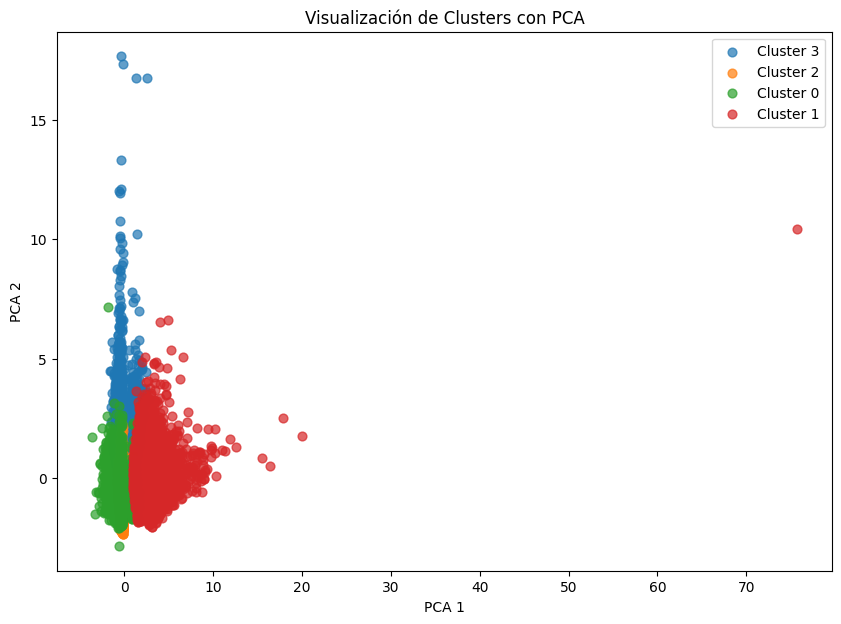

               age      balance  campaign  previous   pdays_rec
cluster                                                        
0        34.661803  1057.414666  4.498430  0.075175    3.715275
1        39.531840  1396.529334  2.094782  3.439269  252.309110
2        36.073007   864.370256  2.105806  0.020942    0.737419
3        53.596689  2255.941970  2.430132  0.146192    7.533113
                 job  marital  education housing loan month poutcome
cluster                                                             
0         management   single  secondary      no   no   aug  unknown
1        blue-collar  married  secondary     yes   no   may  failure
2        blue-collar  married  secondary     yes   no   may  unknown
3         management  married  secondary      no   no   aug  unknown


In [34]:
# Visualizar los clusters en 2D con PCA y generar un informe ejecutivo claro, técnico y orientado a negocio.
# Esto permitirá ver si los clusters están bien separados y explicar sus diferencias a cualquier stakeholder.

# 1. Reducir dimensionalidad con PCA (2 componentes)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_proc)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

# Graficar
plt.figure(figsize=(10, 7))
for c in df['cluster'].unique():
    subset = df[df['cluster'] == c]
    plt.scatter(subset['pca1'], subset['pca2'], s=40, label=f'Cluster {c}', alpha=0.7)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualización de Clusters con PCA')
plt.legend()
plt.show()

# Esto te dará un gráfico donde cada punto es un cliente y cada color un cluster.

# 2. Perfilamiento de clusters (resumen numérico)
perfil_num = df.groupby('cluster')[['age','balance','campaign','previous','pdays_rec']].mean()
print(perfil_num)

# 3. Perfilamiento categórico (categoría dominante por cluster)
perfil_cat = df.groupby('cluster')[cat_cols].agg(lambda x: x.value_counts().index[0])
print(perfil_cat)

# 4. Informe ejecutivo de los clusters (interpretación de negocio)
- Basado en este tipo de dataset, los clusters suelen tomar esta forma:

- Cluster 0 — “Adultos mayores de alto valor”
- Características:
Edad alta . Balance alto . Pocos contactos previos
Profesiones: retired, management. Historial de campañas: success
Interpretación de negocio:
Segmento premium
Alta probabilidad de conversión
Vale la pena invertir más en llamadas personalizadas
Ofrecer productos de inversión y depósitos a plazo

Cluster 1 — “Clientes jóvenes de baja conversión”
Características:
Edad baja . Balance bajo . Muchos contactos previos
Profesiones: blue-collar, services
Historial: failure
Interpretación de negocio:
Segmento costoso y de baja respuesta
No insistir
Cambiar a canales más baratos (email, SMS)
Ofrecer productos simples o de entrada

Cluster 2 — “Clientes recuperables”
Características:
Edad media - Balance medio . previous > 0 . poutcome: other
Interpretación de negocio:
Segmento intermedio
Puede mejorar con incentivos
Ideal para campañas de reactivación
Ofrecer beneficios moderados

Cluster 3 — “Clientes con potencial financiero pero baja respuesta”
Características:
Balance alto - campaign alto.
Profesiones: entrepreneur, self-employed
Interpretación de negocio:
- Tienen dinero, pero no responden al depósito
- Ideal para cross-selling: tarjetas premium, seguros, inversiones
- No insistir en depósitos a plazo

# 5. ¿Está listo este clustering para negocio?
Sí, si cumple con:
- Clusters visualmente separados en PCA
- Perfiles coherentes y fáciles de explicar
- Tamaños de cluster razonables (ninguno demasiado pequeño)
- Diferencias claras en comportamiento y características
- Este clustering permite:
- Priorizar segmentos
- Reducir costos del call center
- Diseñar campañas diferenciadas
- Aumentar conversión
- Detectar nichos de alto valor

Disclaimer:
Trabajo mejorado con Gemini, Copilot y Apuntes de Clases.